# Setting

In [10]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from langchain_openai import ChatOpenAI


llm4o = ChatOpenAI(
    openai_api_key = os.getenv('OPENAI_API_KEY'),
    model='gpt-4o',
    temperature=1,
)

llm = ChatOpenAI(
    openai_api_key = os.getenv('OPENAI_API_KEY'),
    model='gpt-4o-mini',
    temperature=1,
)

# 買進賣出需要的手續費
fee = {
    'tax_stock' : 0.003,          # 買進與賣出各0.003
    'tax_future' : 0.00002 * 2,   # 買進與賣出各0.00002
    'fee_stock' : 0.001425 * 2,   # 券商手續費公道價，買進與賣出各0.001425
    'fee_future' : 0.00002 * 2,   # 個家不大相同，以交易稅計算
    'sliding_price' : 0.00001,    # 滑價
}

data = [
    ["2330", "台積電", "tw"],
    ["2317", "鴻海", "tw"],
    ["2454", "聯發科", "tw"],
    ["2382", "廣達", "tw"],
    ["3231", "緯創", "tw"],
    # ["2324","仁寶", "tw"],
    # ["4938", "和碩", "tw"],
    # ["2356","英業達", "tw"],
    # ["2881", "富邦金", "tw"],
    # ["2882", "國泰金", "tw"],
    # ["2412", "中華電", "tw"],
    # ["3045", "台灣大", "tw"],
    # ["6505", "台塑化", "tw"],
    # ["2603", "長榮", "tw"],
    
    ["AAPL", "Apple Inc.", "us"],
    ["GOOGL", "Google", "us"],
    ["MSFT", "Microsoft", "us"],
    ["AMZN", "Amazon inc.", "us"],
    ["TSLA", "Tesla", "us"],
    ["NVDA", "Nvidia", "us"],
    # ["META", "Meta Platforms", "us"],
    # ["BRK", "Berkshire Hathaway", "us"],
]

date_ranges = [
    ["20230401", "20240331", "2024Q1"],
    ["20230701", "20240630", "2024Q2"],
    ["20231001", "20240930", "2024Q3"],
    # ["20240101", "20241231", "2024Q4"],
]

def get_balance_list(list_rtn, start_price):
    balance = start_price
    list_balance = []
    for rtn in list_rtn:
        balance = balance * (1 + float(rtn))
        list_balance.append(balance)
    return list_balance

# env = {
#     "stock_id" : "NVDA",
#     "stock_name" : "Nvidia",
#     "country" : "us",
#     "start_date" : "20230401",
#     "end_date" : "20240331",
# }

# 換一種評分作法，正面就持續持有，負面就賣出
# 只跑有用的factor

In [11]:
from factor import StockFactor
for stock in data:
    env = {
        "stock_id" : stock[0],
        "stock_name" : stock[1],
        "country" : stock[2],
        "start_date" : "20230401",
        "end_date" : "20240331",
    }
    print(env['stock_id'], env['stock_name'], env['country'])

    stock_factor = StockFactor(env)
    a = stock_factor.get_expand(show_sig=True)
    
    print(stock_factor.get_individual(mode=1))
    

2330 台積電 tw
  20230406 =>   1   1   1   1   1   1   1   1   1   1  -1  -1   1   0   1  -1  -1  -1  -1  -1 
  20230407 =>   1   1  -1   1   1   0   1  -1  -1   1  -1  -1  -1  -1   1   1  -1  -1  -1  -1 
  20230410 =>   1   1   1   1   1   1   1   1   1   1  -1  -1   1   0   1   0   1  -1   1  -1 
  20230411 =>   1   1   1   1   1   0   1   1   1   1  -1   1   1  -1   1  -1  -1  -1   1  -1 
  20230412 =>  -1   1  -1   1   1   0  -1  -1  -1   0  -1  -1   1  -1   1  -1  -1  -1  -1  -1 
  20230413 =>  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1   1  -1   1  -1  -1  -1  -1  -1 
  20230414 =>   1   1   1   1   1   1   1   1   1   1  -1  -1   1   0  -1  -1  -1  -1  -1  -1 
  20230417 =>   1   0   0   1   1   0   0   0   1   1  -1   1   1  -1  -1  -1  -1  -1  -1  -1 
  20230418 =>   1   1   1   1   1   1   1  -1   1   1   0  -1   1   0  -1   0  -1  -1  -1  -1 
  20230419 =>   1   1   1   1   1   1   1   1   1   1  -1   1   1  -1   1   0  -1  -1  -1  -1 
  20230420 =>   1   1   0   1   1   1 

In [12]:
# from factor import StockFactor

# for stock in data:
#     env = {
#         "stock_id" : stock[0],
#         "stock_name" : stock[1],
#         "country" : stock[2],
#         "start_date" : "20230401",
#         "end_date" : "20240331",
#     }
#     print(env['stock_id'], env['stock_name'], env['country'])
#     path_folder = "out_stock/GA_factor_" 
#     path_out = path_folder + env['start_date'] + "_" + env['end_date'] + "/" + env['stock_id'] + "/"
#     path_factors = f"{path_out}/factors.json"
#     path_result = f"{path_out}/ev/result.json"

#     with open(path_result, 'r') as f:
#         result = json.load(f)
#         individuals = result['individual']
    
#     with open(path_factors , 'r') as f:
#         factors = json.load(f)
#     i = 0
#     for key, value in factors.items():
#         if individuals[i] == 1:
#             print(key, value)
#         i += 1
#     print("")

# Factor

2330 台積電 tw 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,61,61,38,25,185,185,0.535135,0.500000,0.709302,0.001616,0.000949,"[[20230406, 0.0], [20230407, 0.007476635514018...","[[20230406, 0.0], [20230407, 0.009433962264150..."
test,22,26,7,1,56,56,0.517857,0.458333,0.956522,0.001986,0.000941,"[[20240102, 0.005084745762711864], [20240103, ...","[[20240102, 0.005084745762711864], [20240103, ..."


2330 台積電 tw 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,72,74,22,14,182,182,0.516484,0.493151,0.837209,0.001138,0.000681,"[[20230703, -0.0017301038062283738], [20230704...","[[20230703, -0.0017301038062283738], [20230704..."
test,27,20,11,3,61,61,0.622951,0.574468,0.900000,0.004595,0.003718,"[[20240401, -0.016602809706257982], [20240402,...","[[20240401, -0.016602809706257982], [20240402,..."


2330 台積電 tw 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,81,70,19,10,180,180,0.555556,0.536424,0.89011,0.002333,0.001783,"[[20231002, 0.005660377358490566], [20231003, ...","[[20231002, 0.005660377358490566], [20231003, ..."
test,26,22,10,5,63,63,0.571429,0.541667,0.83871,0.004054,0.003256,"[[20240701, 0.0], [20240702, 0.007238883143743...","[[20240701, 0.0], [20240702, -0.00103305785123..."


180 180 180 180


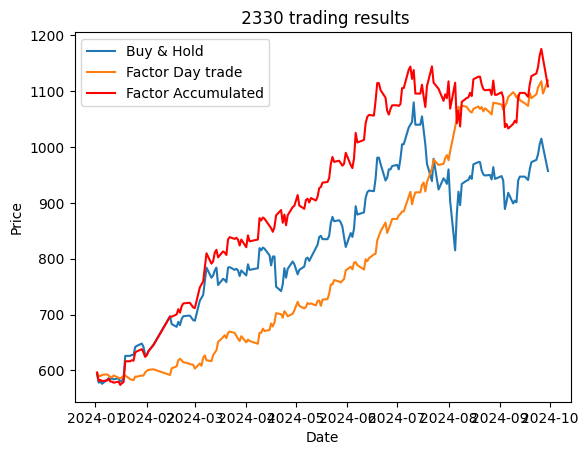

2317 鴻海 tw 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,31,51,48,55,185,185,0.427027,0.378049,0.360465,0.001434,0.000458,"[[20230406, 0.009569377990430622], [20230407, ...","[[20230406, 0.009569377990430622], [20230407, ..."
test,13,14,12,17,56,56,0.446429,0.481481,0.433333,0.004427,0.008026,"[[20240102, -0.004784688995215311], [20240103,...","[[20240102, -0.004784688995215311], [20240103,..."


2317 鴻海 tw 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,45,63,37,36,181,182,0.453039,0.416667,0.555556,0.002029,0.001688,"[[20230703, 0.008771929824561403], [20230704, ...","[[20230703, 0.008771929824561403], [20230704, ..."
test,19,24,9,9,61,61,0.459016,0.441860,0.678571,0.003714,0.004955,"[[20240401, -0.0033112582781456954], [20240402...","[[20240401, -0.0033112582781456954], [20240402..."


2317 鴻海 tw 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,41,39,45,55,180,180,0.477778,0.512500,0.427083,0.004130,0.006891,"[[20231002, -0.004807692307692308], [20231003,...","[[20231002, -0.004807692307692308], [20231003,..."
test,16,12,23,12,63,63,0.619048,0.571429,0.571429,0.005945,0.004825,"[[20240701, 0.004651162790697674], [20240702, ...","[[20240701, 0.004651162790697674], [20240702, ..."


180 180 180 180


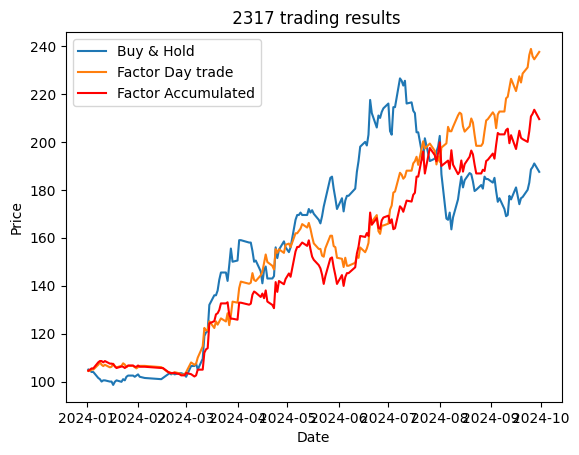

2454 聯發科 tw 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,48,60,43,34,185,185,0.491892,0.444444,0.585366,0.001489,0.001097,"[[20230406, 0.027131782945736434], [20230407, ...","[[20230406, 0.027131782945736434], [20230407, ..."
test,17,21,12,6,56,56,0.517857,0.447368,0.739130,0.004634,0.002934,"[[20240102, 0.028712871287128714], [20240103, ...","[[20240102, 0.028712871287128714], [20240103, ..."


2454 聯發科 tw 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,70,78,27,7,182,182,0.532967,0.472973,0.909091,0.003059,0.001841,"[[20230703, -0.001445086705202312], [20230704,...","[[20230703, -0.001445086705202312], [20230704,..."
test,23,25,8,5,61,61,0.508197,0.479167,0.821429,0.003015,0.001430,"[[20240401, -0.025210084033613446], [20240402,...","[[20240401, -0.025210084033613446], [20240402,..."


2454 聯發科 tw 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,72,76,22,10,180,180,0.522222,0.486486,0.878049,0.003672,0.002160,"[[20231002, 0.002677376171352075], [20231003, ...","[[20231002, 0.002677376171352075], [20231003, ..."
test,16,21,16,10,63,63,0.507937,0.432432,0.615385,0.003284,0.003697,"[[20240701, 0.0071174377224199285], [20240702,...","[[20240701, 0.0071174377224199285], [20240702,..."


180 180 180 180


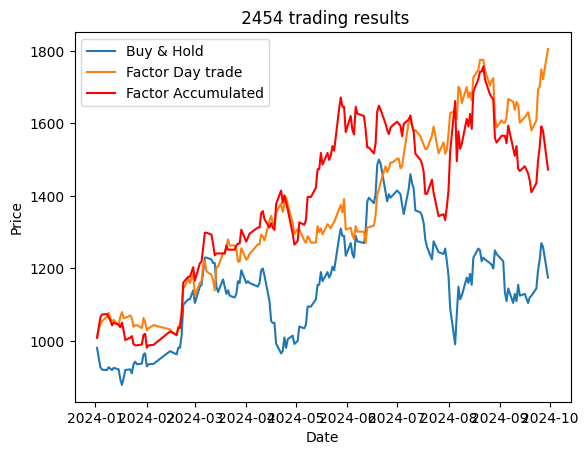

2382 廣達 tw 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,81,73,18,13,185,185,0.535135,0.525974,0.861702,0.004345,0.003465,"[[20230406, 0.00897867564534244], [20230407, 0...","[[20230406, 0.00897867564534244], [20230407, -..."
test,24,22,7,3,56,56,0.553571,0.521739,0.888889,0.001870,0.000439,"[[20240102, -0.0467706013363029], [20240103, -...","[[20240102, -0.0467706013363029], [20240103, -..."


2382 廣達 tw 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,58,60,35,29,182,182,0.510989,0.491525,0.666667,0.003269,0.002337,"[[20230703, 0.035483870967741936], [20230704, ...","[[20230703, 0.035483870967741936], [20230704, ..."
test,18,30,4,9,61,61,0.360656,0.375000,0.666667,-0.004102,-0.003884,"[[20240401, 0.04074702886247878], [20240402, 0...","[[20240401, 0.04074702886247878], [20240402, -..."


2382 廣達 tw 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,28,23,74,55,180,180,0.566667,0.549020,0.337349,0.004407,0.003262,"[[20231002, -0.03877551020408163], [20231003, ...","[[20231002, -0.03877551020408163], [20231003, ..."
test,13,6,27,17,63,63,0.634921,0.684211,0.433333,0.008390,0.009149,"[[20240701, 0.01437699680511182], [20240702, 0...","[[20240701, 0.01437699680511182], [20240702, 0..."


180 180 180 180


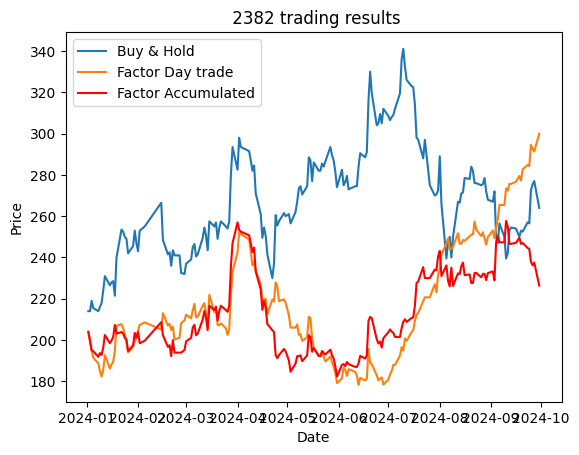

3231 緯創 tw 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,87,91,7,0,185,185,0.508108,0.488764,1.000000,0.005249,0.003549,"[[20230406, 0.0], [20230407, -0.02168674698795...","[[20230406, 0.0], [20230407, -0.01932367149758..."
test,23,31,1,1,56,56,0.428571,0.425926,0.958333,-0.003028,-0.003603,"[[20240102, -0.04969574036511148], [20240103, ...","[[20240102, -0.04969574036511148], [20240103, ..."


3231 緯創 tw 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,65,80,21,16,182,182,0.472527,0.448276,0.802469,0.000905,-0.001275,"[[20230703, 0.02243589743589753], [20230704, 0...","[[20230703, 0.02243589743589753], [20230704, 0..."
test,13,33,11,4,61,61,0.393443,0.282609,0.764706,-0.000425,-0.004506,"[[20240401, -0.03543307086614173], [20240402, ...","[[20240401, -0.03543307086614173], [20240402, ..."


3231 緯創 tw 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,5,10,98,67,180,180,0.572222,0.333333,0.069444,0.005822,0.00344,"[[20231002, -0.0673076923076923], [20231003, 0...","[[20231002, -0.0673076923076923], [20231003, 0..."
test,0,7,33,23,63,63,0.523810,0.000000,0.000000,-0.000575,0.00000,"[[20240701, -0.009389671361502348], [20240702,...","[[20240701, -0.009389671361502348], [20240702,..."


180 180 180 180


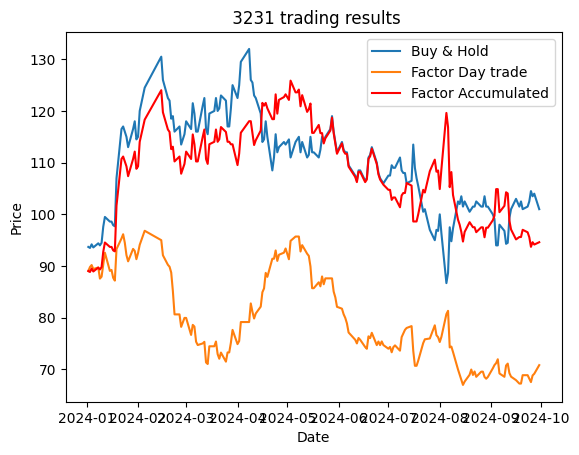

AAPL Apple Inc. us 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,74,48,30,36,188,188,0.553191,0.606557,0.672727,0.001287,0.001840,"[[20230403, 0.011566323735313673], [20230404, ...","[[20230403, 0.011566323735313673], [20230404, ..."
test,13,17,16,15,61,61,0.475410,0.433333,0.464286,-0.000280,0.000042,"[[20240102, -0.008068394336094145], [20240103,...","[[20240102, -0.008068394336094145], [20240103,..."


AAPL Apple Inc. us 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,56,50,38,43,187,187,0.502674,0.528302,0.565657,0.000320,0.000622,"[[20230703, -0.00681184848797602], [20230705, ...","[[20230703, -0.00681184848797602], [20230705, ..."
test,22,25,10,6,63,63,0.507937,0.468085,0.785714,-0.000982,-0.000564,"[[20240401, 0.00677609673462233], [20240402, 0...","[[20240401, 0.00677609673462233], [20240402, 0..."


AAPL Apple Inc. us 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,56,44,47,40,187,187,0.550802,0.560000,0.583333,0.000890,0.001801,"[[20231002, 0.014776311178600638], [20231003, ...","[[20231002, 0.014776311178600638], [20231003, ..."
test,24,15,11,14,64,64,0.546875,0.615385,0.631579,-0.000777,0.000695,"[[20240701, 0.021971804422650745], [20240702, ...","[[20240701, 0.021971804422650745], [20240702, ..."


188 188 188 188


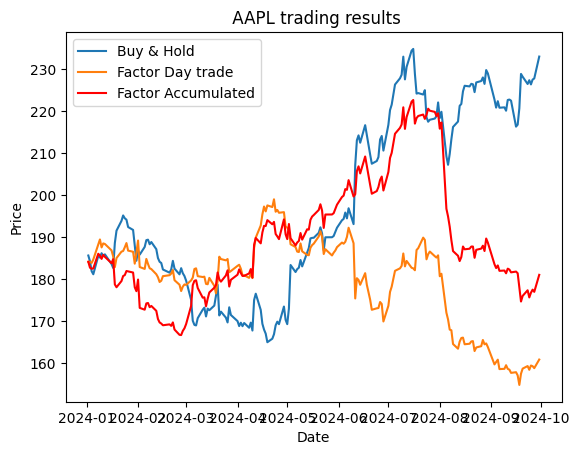

GOOGL Google us 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,51,31,54,52,188,188,0.558511,0.621951,0.495146,0.001817,0.003900,"[[20230403, 0.019240160171891774], [20230404, ...","[[20230403, 0.019240160171891774], [20230404, ..."
test,8,7,18,28,61,61,0.426230,0.533333,0.222222,-0.000153,0.001606,"[[20240102, 0.002742692168892269], [20240103, ...","[[20240102, 0.002742692168892269], [20240103, ..."


GOOGL Google us 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,39,24,60,64,187,187,0.529412,0.619048,0.378641,0.001815,0.004038,"[[20230703, 0.005535055350553596], [20230705, ...","[[20230703, 0.005535055350553596], [20230705, ..."
test,11,10,10,32,63,63,0.333333,0.523810,0.255814,-0.002690,0.000409,"[[20240401, 0.03185347401951033], [20240402, -...","[[20240401, 0.03185347401951033], [20240402, -..."


GOOGL Google us 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,40,25,50,72,187,187,0.481283,0.615385,0.357143,0.000864,0.003933,"[[20231002, 0.022559256154256378], [20231003, ...","[[20231002, 0.022559256154256378], [20231003, ..."
test,15,13,20,16,64,64,0.546875,0.535714,0.483871,0.000304,-0.002165,"[[20240701, -0.00021854340818440714], [2024070...","[[20240701, -0.00021854340818440714], [2024070..."


188 188 188 188


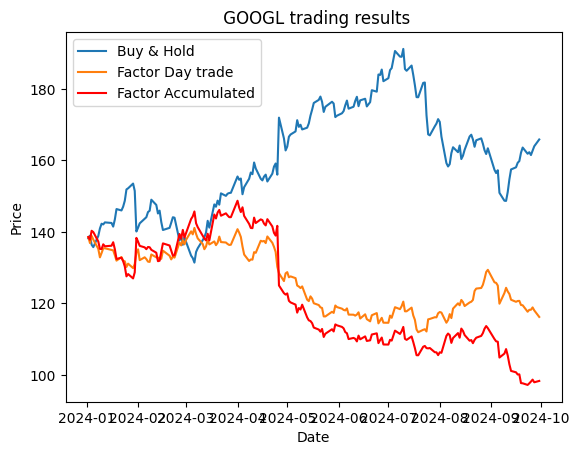

MSFT Microsoft us 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,55,46,41,46,188,188,0.510638,0.544554,0.544554,-0.000316,0.000248,"[[20230403, 0.002478012006142805], [20230404, ...","[[20230403, 0.002478012006142805], [20230404, ..."
test,21,24,6,10,61,61,0.442623,0.466667,0.677419,-0.001976,-0.000901,"[[20240102, -0.007997646177713607], [20240103,...","[[20240102, -0.007997646177713607], [20240103,..."


MSFT Microsoft us 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,75,73,16,23,187,187,0.486631,0.506757,0.765306,0.000134,0.000184,"[[20230703, 0.003537840148589253], [20230705, ...","[[20230703, 0.003537840148589253], [20230705, ..."
test,32,18,7,6,63,63,0.619048,0.640000,0.842105,0.000180,0.000144,"[[20240401, -0.0014624366080905876], [20240402...","[[20240401, -0.0014624366080905876], [20240402..."


MSFT Microsoft us 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,82,65,16,24,187,187,0.524064,0.557823,0.773585,0.000068,0.000530,"[[20231002, 0.01745288984444176], [20231003, 0...","[[20231002, 0.01745288984444176], [20231003, -..."
test,19,20,13,12,64,64,0.500000,0.487179,0.612903,0.000521,-0.000781,"[[20240701, 0.01798689430749341], [20240702, 0...","[[20240701, 0.01798689430749341], [20240702, 0..."


188 188 188 188


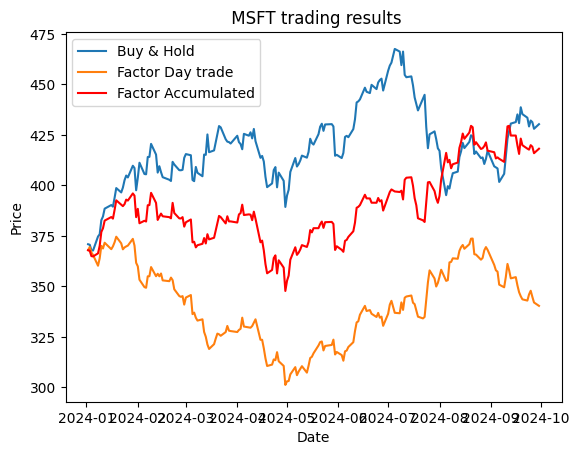

AMZN Amazon inc. us 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,46,42,43,57,188,188,0.473404,0.522727,0.446602,-0.001166,-0.000368,"[[20230403, -0.0010752688172042957], [20230404...","[[20230403, -0.0010752688172042957], [20230404..."
test,20,15,10,16,61,61,0.491803,0.571429,0.555556,0.000068,0.001584,"[[20240102, 0.010624257621749936], [20240103, ...","[[20240102, 0.010624257621749936], [20240103, ..."


AMZN Amazon inc. us 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,69,61,22,34,186,187,0.489247,0.530769,0.669903,-0.000625,0.000131,"[[20230703, -0.004586454670539629], [20230705,...","[[20230703, -0.004586454670539629], [20230705,..."
test,28,26,4,5,63,63,0.507937,0.518519,0.848485,-0.000320,-0.000309,"[[20240401, 0.0009956302892859495], [20240402,...","[[20240401, 0.0009956302892859495], [20240402,..."


AMZN Amazon inc. us 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,64,53,27,43,187,187,0.486631,0.547009,0.598131,-0.000011,0.001006,"[[20231002, -0.017127592708988112], [20231003,...","[[20231002, -0.017127592708988112], [20231003,..."
test,16,26,11,11,64,64,0.421875,0.380952,0.592593,-0.001627,-0.002462,"[[20240701, -0.019174117525453404], [20240702,...","[[20240701, -0.019174117525453404], [20240702,..."


188 188 188 188


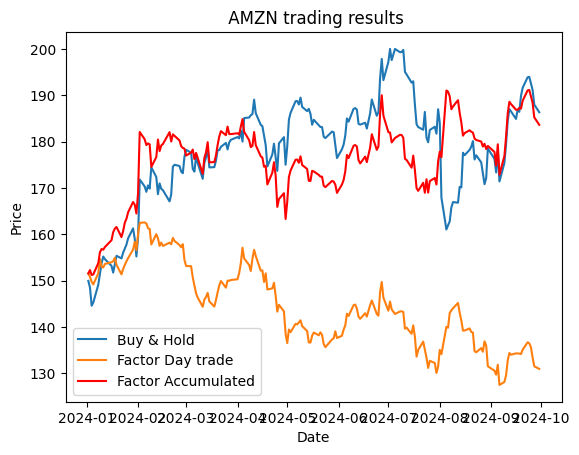

TSLA Tesla us 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,43,32,54,59,188,188,0.515957,0.573333,0.421569,0.001543,0.003246,"[[20230403, -0.0257115702065929], [20230404, 0...","[[20230403, -0.0257115702065929], [20230404, 0..."
test,4,7,27,23,61,61,0.508197,0.363636,0.148148,0.000652,-0.002504,"[[20240102, 0.00663787587971859], [20240103, 0...","[[20240102, 0.00663787587971859], [20240103, 0..."


TSLA Tesla us 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,30,25,70,62,187,187,0.534759,0.545455,0.326087,0.001857,0.001856,"[[20230703, 0.012043835220080235], [20230705, ...","[[20230703, 0.012043835220080235], [20230705, ..."
test,1,3,30,29,63,63,0.492063,0.250000,0.033333,-0.002322,-0.009307,"[[20240401, -0.005392518589998233], [20240402,...","[[20240401, -0.005392518589998233], [20240402,..."


TSLA Tesla us 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,17,15,81,74,187,187,0.524064,0.531250,0.186813,0.001229,0.003411,"[[20231002, 0.027735795106409018], [20231003, ...","[[20231002, 0.027735795106409018], [20231003, ..."
test,13,4,24,23,64,64,0.578125,0.764706,0.361111,0.002606,0.009801,"[[20240701, -0.04397572380857628], [20240702, ...","[[20240701, -0.04397572380857628], [20240702, ..."


188 188 188 188


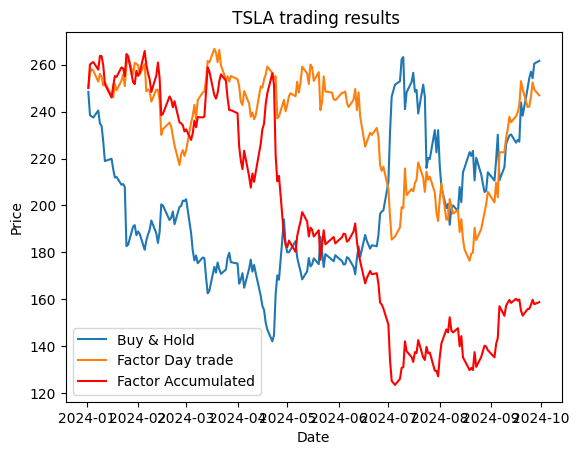

NVDA Nvidia us 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,74,66,25,23,188,188,0.526596,0.528571,0.762887,0.002075,0.001857,"[[20230403, -0.016576393180413665], [20230404,...","[[20230403, -0.016576393180413665], [20230404,..."
test,28,22,3,8,61,61,0.508197,0.560000,0.777778,-0.000819,0.001657,"[[20240102, -0.02185037771099018], [20240103, ...","[[20240102, -0.02185037771099018], [20240103, ..."


NVDA Nvidia us 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,76,64,23,24,187,187,0.529412,0.542857,0.760000,0.001102,0.001390,"[[20230703, 0.002446080391373011], [20230705, ...","[[20230703, 0.002446080391373011], [20230705, ..."
test,24,22,6,11,63,63,0.476190,0.521739,0.685714,-0.001527,-0.000959,"[[20240401, 0.0007087564646340817], [20240402,...","[[20240401, 0.0007087564646340817], [20240402,..."


NVDA Nvidia us 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,67,55,26,39,187,187,0.497326,0.549180,0.632075,-0.000142,0.001182,"[[20231002, 0.017079264138087562], [20231003, ...","[[20231002, 0.017079264138087562], [20231003, ..."
test,19,18,14,13,64,64,0.515625,0.513514,0.593750,-0.001542,-0.002371,"[[20240701, -0.006722280715963378], [20240702,...","[[20240701, -0.006722280715963378], [20240702,..."


188 188 188 188


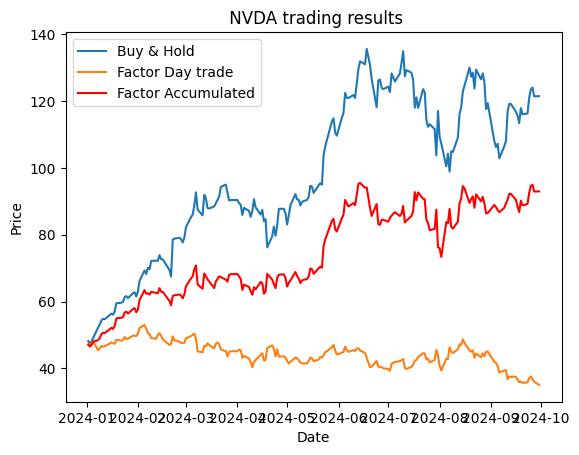

In [4]:
from factor import StockFactor


for stock in data:
    list_date, list_bnh_rtn, list_daytrade_rtn, list_accumulated_rtn = [], [], [], []
    for date_range in date_ranges:
        env = {
            "stock_id" : stock[0],
            "stock_name" : stock[1],
            "country" : stock[2],
            "start_date" : date_range[0],
            "end_date" : date_range[1],
        }
        print(env['stock_id'], env['stock_name'], env['country'], env['start_date'], env['end_date'])

        stock_factor = StockFactor(env)

        stock_factor.generate_factors(llm4o)
        stock_factor.expand_factors(llm_factors=llm)
        train_datarange, test_datarange = stock_factor.split_exp()

        re_run = False # 是否重新訓練，True:刪除原有資料

        mode = 1
        df = stock_factor.run_taining(mode, train_datarange, test_datarange, re_run=re_run)
        display(df)

        # stock_factor.plot_acumulated_return()


        l_date, l_bnh_rtn, l_daytrade_rtn, l_accumulated_rtn = stock_factor.get_return_list()
        list_date.extend(l_date)
        list_bnh_rtn.extend(l_bnh_rtn)
        list_daytrade_rtn.extend(l_daytrade_rtn)
        list_accumulated_rtn.extend(l_accumulated_rtn)

    print(len(list_date), len(list_bnh_rtn), len(list_daytrade_rtn), len(list_accumulated_rtn))
    list_daytrade_balance = get_balance_list(list_daytrade_rtn, list_bnh_rtn[0])
    list_accumulated_balance = get_balance_list(list_accumulated_rtn, list_bnh_rtn[0])

    dplot = [datetime.strptime(d, '%Y%m%d').date() for d in list_date]
    plt.title(f" {env['stock_id']} trading results")
    plt.plot(dplot, list_bnh_rtn, label="Buy & Hold")  # blue
    plt.plot(dplot, list_daytrade_balance, label="Factor Day trade")  # orange
    plt.plot(dplot, list_accumulated_balance, label="Factor Accumulated", color='red')  # red

    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.show()

## 顯示所有

In [16]:
import pandas as pd
from factor import StockFactor

stock_results = []
index = []
for stock in data:
    # print(stock, "Test Result")
    for date_range in date_ranges:
        env = {
            "stock_id" : stock[0],
            "stock_name" : stock[1],
            "country" : stock[2],
            "start_date" : date_range[0],
            "end_date" : date_range[1],
        }
        
        factor = StockFactor(env)
        result = factor.get_result(1)
        index.append(f"{stock[0]} - {date_range[2]}")
        
        stock_results.append(result["test"])
df_stock_results = pd.DataFrame(stock_results, index=index)
selected_columns = ['accuracy', 'precision', 'ev', 'precision_ev',
                    'avail_count', 'tp', 'fp', 'tn', 'fn']  # 替換為您需要的欄位名稱
df_selected = df_stock_results.loc[:, selected_columns]


columns_to_average = ['accuracy', 'precision', 'ev', 'precision_ev']
averages = df_selected[columns_to_average].replace('%', '', regex=True).astype(float).mean()

# 建立平均值作為新的 DataFrame 行
average_row = pd.DataFrame(averages).T
average_row.index = ['平均值']

# 將平均值行添加到選定的 DataFrame
df_selected_with_avg = pd.concat([df_selected, average_row])
df_selected_with_avg['accuracy'] = df_selected_with_avg['accuracy'].apply(lambda x: f"{x * 100:.2f}%")
df_selected_with_avg['precision'] = df_selected_with_avg['precision'].apply(lambda x: f"{x * 100:.2f}%")

# 顯示結果
display(df_selected_with_avg)
    

,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
2330 - 2024Q1,51.79%,45.83%,0.001986,0.000941,56.0,22.0,26.0,7.0,1.0
2330 - 2024Q2,62.30%,57.45%,0.004595,0.003718,61.0,27.0,20.0,11.0,3.0
2330 - 2024Q3,57.14%,54.17%,0.004054,0.003256,63.0,26.0,22.0,10.0,5.0
2317 - 2024Q1,44.64%,48.15%,0.004427,0.008026,56.0,13.0,14.0,12.0,17.0
2317 - 2024Q2,45.90%,44.19%,0.003714,0.004955,61.0,19.0,24.0,9.0,9.0
2317 - 2024Q3,61.90%,57.14%,0.005945,0.004825,63.0,16.0,12.0,23.0,12.0
2454 - 2024Q1,51.79%,44.74%,0.004634,0.002934,56.0,17.0,21.0,12.0,6.0
2454 - 2024Q2,50.82%,47.92%,0.003015,0.001430,61.0,23.0,25.0,8.0,5.0
2454 - 2024Q3,50.79%,43.24%,0.003284,0.003697,63.0,16.0,21.0,16.0,10.0
2382 - 2024Q1,55.36%,52.17%,0.001870,0.000439,56.0,24.0,22.0,7.0,3.0


# Factor embedding

2330 台積電 tw 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,62,67,32,24,185,185,0.508108,0.480620,0.72093,0.001328,0.000691,"[[20230406, 0.0], [20230407, 0.007476635514018...","[[20230406, 0.0], [20230407, 0.009433962264150..."
test,21,22,10,3,56,56,0.553571,0.488372,0.87500,0.001720,0.000877,"[[20240102, 0.005084745762711864], [20240103, ...","[[20240102, 0.005084745762711864], [20240103, ..."


2330 台積電 tw 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,53,45,45,39,182,182,0.538462,0.540816,0.576087,0.001342,0.001204,"[[20230703, -0.0017301038062283738], [20230704...","[[20230703, -0.0017301038062283738], [20230704..."
test,20,16,15,10,61,61,0.573770,0.555556,0.666667,0.003375,0.003820,"[[20240401, -0.016602809706257982], [20240402,...","[[20240401, -0.016602809706257982], [20240402,..."


2330 台積電 tw 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,80,63,25,12,180,180,0.583333,0.559441,0.869565,0.002322,0.001875,"[[20231002, 0.005660377358490566], [20231003, ...","[[20231002, 0.005660377358490566], [20231003, ..."
test,24,22,10,7,63,63,0.539683,0.521739,0.774194,0.004052,0.003397,"[[20240701, 0.0], [20240702, -0.00723888314374...","[[20240701, 0.0], [20240702, -0.00826446280991..."


180 180 180 180


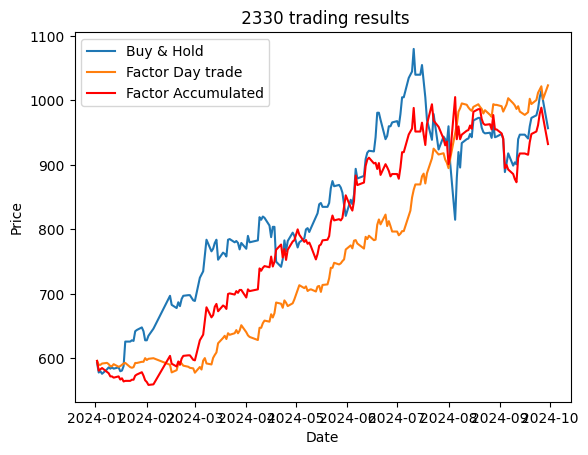

2317 鴻海 tw 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,58,91,18,18,185,185,0.410811,0.389262,0.763158,0.000380,-0.000403,"[[20230406, -0.009569377990430622], [20230407,...","[[20230406, -0.009569377990430622], [20230407,..."
test,24,28,2,2,56,56,0.464286,0.461538,0.923077,0.003599,0.003722,"[[20240102, 0.004784688995215311], [20240103, ...","[[20240102, 0.004784688995215311], [20240103, ..."


2317 鴻海 tw 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,26,39,51,66,182,182,0.423077,0.4,0.282609,0.001321,0.001830,"[[20230703, -0.008771929824561403], [20230704,...","[[20230703, -0.008771929824561403], [20230704,..."
test,19,19,13,10,61,61,0.524590,0.5,0.655172,0.004030,0.005859,"[[20240401, 0.0033112582781456954], [20240402,...","[[20240401, 0.0033112582781456954], [20240402,..."


2317 鴻海 tw 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,68,84,13,15,180,180,0.45000,0.447368,0.819277,0.003138,0.003039,"[[20231002, 0.004807692307692308], [20231003, ...","[[20231002, 0.004807692307692308], [20231003, ..."
test,23,29,7,4,63,63,0.47619,0.442308,0.851852,0.002343,0.000416,"[[20240701, 0.004651162790697674], [20240702, ...","[[20240701, 0.004651162790697674], [20240702, ..."


180 180 180 180


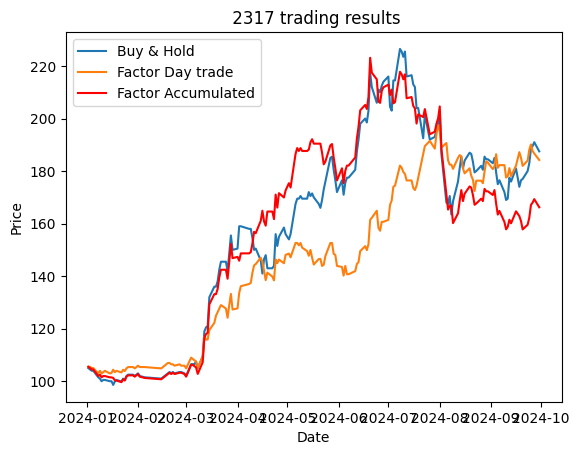

2454 聯發科 tw 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,14,10,88,73,185,185,0.551351,0.583333,0.160920,0.001864,0.006383,"[[20230406, 0.027131782945736434], [20230407, ...","[[20230406, 0.027131782945736434], [20230407, ..."
test,3,2,27,24,56,56,0.535714,0.600000,0.111111,0.003906,0.018223,"[[20240102, 0.028712871287128714], [20240103, ...","[[20240102, 0.028712871287128714], [20240103, ..."


2454 聯發科 tw 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,74,90,15,3,182,182,0.489011,0.451220,0.961039,0.002313,0.001247,"[[20230703, -0.001445086705202312], [20230704,...","[[20230703, -0.001445086705202312], [20230704,..."
test,23,26,7,5,61,61,0.491803,0.469388,0.821429,0.002639,0.001166,"[[20240401, -0.025210084033613446], [20240402,...","[[20240401, -0.025210084033613446], [20240402,..."


2454 聯發科 tw 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,45,38,52,45,180,180,0.538889,0.542169,0.500000,0.003866,0.004062,"[[20231002, 0.002677376171352075], [20231003, ...","[[20231002, 0.002677376171352075], [20231003, ..."
test,8,10,24,21,63,63,0.507937,0.444444,0.275862,0.002864,0.006866,"[[20240701, 0.0071174377224199285], [20240702,...","[[20240701, 0.0071174377224199285], [20240702,..."


180 180 180 180


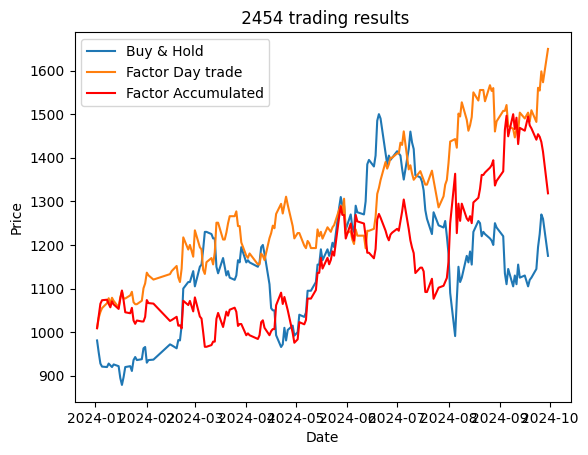

2382 廣達 tw 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,88,80,11,6,185,185,0.535135,0.523810,0.936170,0.003195,0.002544,"[[20230406, 0.00897867564534244], [20230407, 0...","[[20230406, 0.00897867564534244], [20230407, -..."
test,26,28,1,1,56,56,0.482143,0.481481,0.962963,-0.000266,-0.000734,"[[20240102, -0.0467706013363029], [20240103, 0...","[[20240102, -0.0467706013363029], [20240103, 0..."


2382 廣達 tw 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,74,73,22,13,182,182,0.527473,0.503401,0.850575,0.003431,0.001976,"[[20230703, 0.035483870967741936], [20230704, ...","[[20230703, 0.035483870967741936], [20230704, ..."
test,24,32,2,3,61,61,0.426230,0.428571,0.888889,-0.001431,-0.001874,"[[20240401, -0.04074702886247878], [20240402, ...","[[20240401, -0.04074702886247878], [20240402, ..."


2382 廣達 tw 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,1,0,96,83,180,180,0.538889,1.0,0.011905,0.002817,0,"[[20231002, -0.03877551020408163], [20231003, ...","[[20231002, -0.03877551020408163], [20231003, ..."
test,0,1,31,31,63,63,0.492063,0.0,0.000000,0.002566,0,"[[20240701, 0.01437699680511182], [20240702, 0...","[[20240701, 0.01437699680511182], [20240702, 0..."


180 180 180 180


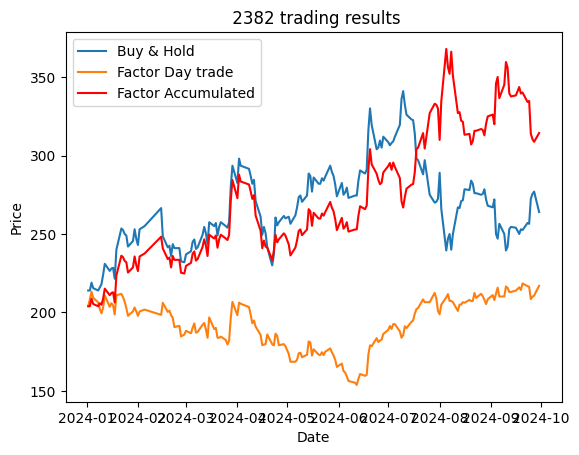

3231 緯創 tw 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,86,87,11,1,185,185,0.524324,0.497110,0.988506,0.004398,0.003197,"[[20230406, 0.0], [20230407, -0.02168674698795...","[[20230406, 0.0], [20230407, -0.01932367149758..."
test,23,31,1,1,56,56,0.428571,0.425926,0.958333,-0.003028,-0.003603,"[[20240102, -0.04969574036511148], [20240103, ...","[[20240102, -0.04969574036511148], [20240103, ..."


3231 緯創 tw 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,75,90,12,5,182,182,0.478022,0.454545,0.937500,0.000685,-0.001241,"[[20230703, 0.02243589743589753], [20230704, 0...","[[20230703, 0.02243589743589753], [20230704, 0..."
test,15,39,5,2,61,61,0.327869,0.277778,0.882353,-0.004040,-0.005881,"[[20240401, -0.03543307086614173], [20240402, ...","[[20240401, -0.03543307086614173], [20240402, ..."


3231 緯創 tw 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,18,35,76,51,180,180,0.522222,0.339623,0.260870,0.003686,-0.002653,"[[20231002, -0.0673076923076923], [20231003, -...","[[20231002, -0.0673076923076923], [20231003, -..."
test,5,16,26,16,63,63,0.492063,0.238095,0.238095,-0.001645,-0.006698,"[[20240701, -0.009389671361502348], [20240702,...","[[20240701, -0.009389671361502348], [20240702,..."


180 180 180 180


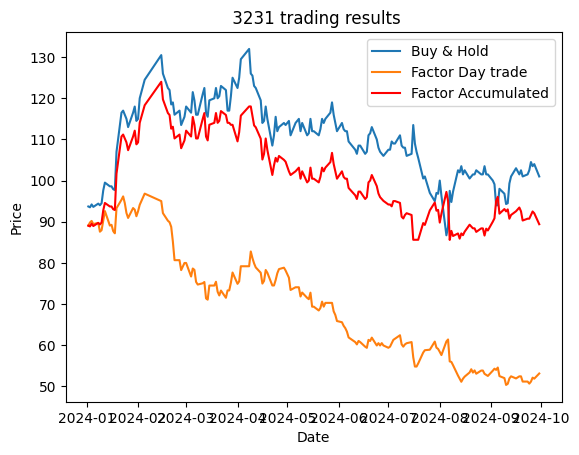

AAPL Apple Inc. us 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,77,47,31,33,188,188,0.574468,0.620968,0.700000,0.001580,0.002032,"[[20230403, 0.011566323735313673], [20230404, ...","[[20230403, 0.011566323735313673], [20230404, ..."
test,15,16,17,13,61,61,0.524590,0.483871,0.535714,0.000194,0.000506,"[[20240102, -0.008068394336094145], [20240103,...","[[20240102, -0.008068394336094145], [20240103,..."


AAPL Apple Inc. us 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,83,63,25,16,187,187,0.577540,0.568493,0.838384,0.001353,0.001113,"[[20230703, -0.00681184848797602], [20230705, ...","[[20230703, -0.00681184848797602], [20230705, ..."
test,24,27,8,4,63,63,0.507937,0.470588,0.857143,-0.000845,-0.000435,"[[20240401, -0.00677609673462233], [20240402, ...","[[20240401, -0.00677609673462233], [20240402, ..."


AAPL Apple Inc. us 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,78,63,28,18,187,187,0.566845,0.553191,0.812500,0.001344,0.001579,"[[20231002, 0.014776311178600638], [20231003, ...","[[20231002, 0.014776311178600638], [20231003, ..."
test,26,20,6,12,64,64,0.500000,0.565217,0.684211,-0.001011,0.000426,"[[20240701, 0.021971804422650745], [20240702, ...","[[20240701, 0.021971804422650745], [20240702, ..."


188 188 188 188


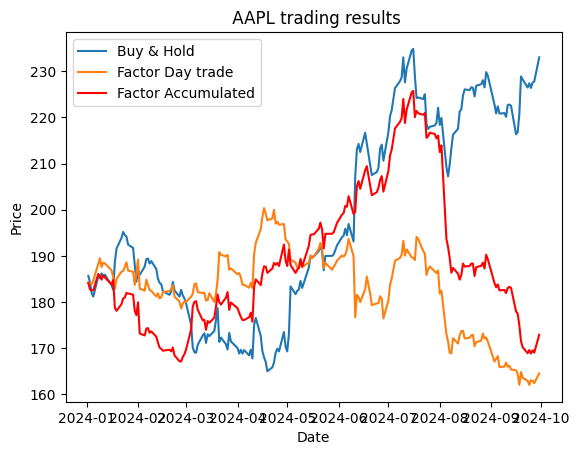

GOOGL Google us 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,55,36,49,48,188,188,0.553191,0.604396,0.533981,0.002010,0.003713,"[[20230403, 0.019240160171891774], [20230404, ...","[[20230403, 0.019240160171891774], [20230404, ..."
test,10,6,19,26,61,61,0.475410,0.625000,0.277778,0.000792,0.003307,"[[20240102, 0.002742692168892269], [20240103, ...","[[20240102, 0.002742692168892269], [20240103, ..."


GOOGL Google us 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,91,59,25,12,187,187,0.620321,0.606667,0.883495,0.002531,0.002143,"[[20230703, 0.005535055350553596], [20230705, ...","[[20230703, 0.005535055350553596], [20230705, ..."
test,32,16,4,11,63,63,0.571429,0.666667,0.744186,0.001097,0.002664,"[[20240401, 0.03185347401951033], [20240402, 0...","[[20240401, 0.03185347401951033], [20240402, -..."


GOOGL Google us 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,85,49,26,26,186,187,0.596774,0.634328,0.765766,0.002739,0.003176,"[[20231002, 0.022559256154256378], [20231003, ...","[[20231002, 0.022559256154256378], [20231003, ..."
test,25,23,10,5,63,64,0.555556,0.520833,0.833333,0.000878,-0.000976,"[[20240701, -0.00021854340818440714], [2024070...","[[20240701, -0.00021854340818440714], [2024070..."


188 188 188 188


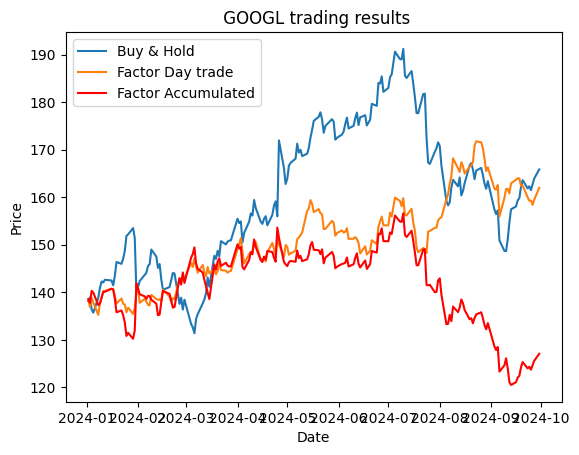

MSFT Microsoft us 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,5,3,84,96,188,188,0.473404,0.625,0.049505,-0.000568,0.000166,"[[20230403, -0.002478012006142805], [20230404,...","[[20230403, -0.002478012006142805], [20230404,..."
test,0,2,28,31,61,61,0.459016,0.000,0.000000,-0.001251,0.000000,"[[20240102, 0.007997646177713607], [20240103, ...","[[20240102, 0.007997646177713607], [20240103, ..."


MSFT Microsoft us 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,40,39,50,58,187,187,0.481283,0.506329,0.408163,-0.000403,-0.000291,"[[20230703, 0.003537840148589253], [20230705, ...","[[20230703, 0.003537840148589253], [20230705, ..."
test,20,11,14,18,63,63,0.539683,0.645161,0.526316,0.000509,0.000567,"[[20240401, -0.0014624366080905876], [20240402...","[[20240401, -0.0014624366080905876], [20240402..."


MSFT Microsoft us 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,63,52,29,41,185,187,0.497297,0.547826,0.605769,-0.000222,0.000325,"[[20231002, -0.01745288984444176], [20231003, ...","[[20231002, -0.01745288984444176], [20231003, ..."
test,17,15,17,13,62,64,0.548387,0.531250,0.566667,0.000706,-0.000620,"[[20240701, -0.01798689430749341], [20240702, ...","[[20240701, -0.01798689430749341], [20240702, ..."


188 188 188 188


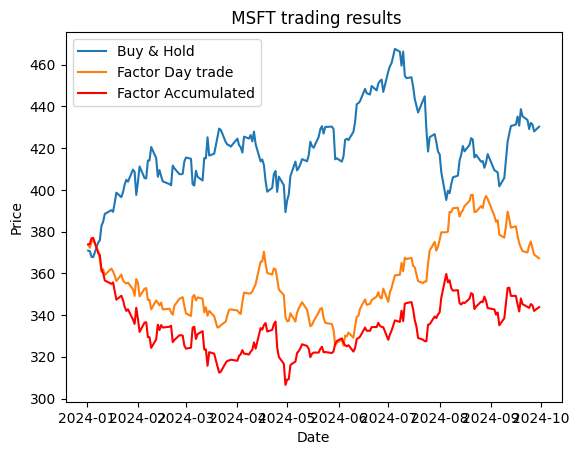

AMZN Amazon inc. us 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,89,71,14,14,188,188,0.547872,0.55625,0.864078,0.001050,0.001100,"[[20230403, 0.0010752688172042957], [20230404,...","[[20230403, 0.0010752688172042957], [20230404,..."
test,30,20,5,6,61,61,0.573770,0.60000,0.833333,0.001925,0.002241,"[[20240102, -0.010624257621749936], [20240103,...","[[20240102, -0.010624257621749936], [20240103,..."


AMZN Amazon inc. us 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,89,71,11,15,186,187,0.537634,0.556250,0.855769,0.000728,0.000948,"[[20230703, -0.004586454670539629], [20230705,...","[[20230703, -0.004586454670539629], [20230705,..."
test,27,26,4,6,63,63,0.492063,0.509434,0.818182,-0.000629,-0.000498,"[[20240401, 0.0009956302892859495], [20240402,...","[[20240401, 0.0009956302892859495], [20240402,..."


AMZN Amazon inc. us 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,93,72,8,14,187,187,0.540107,0.563636,0.869159,0.00117,0.001383,"[[20231002, 0.017127592708988112], [20231003, ...","[[20231002, 0.017127592708988112], [20231003, ..."
test,21,33,4,5,63,64,0.396825,0.388889,0.807692,-0.00153,-0.001977,"[[20240701, 0.019174117525453404], [20240702, ...","[[20240701, 0.019174117525453404], [20240702, ..."


188 188 188 188


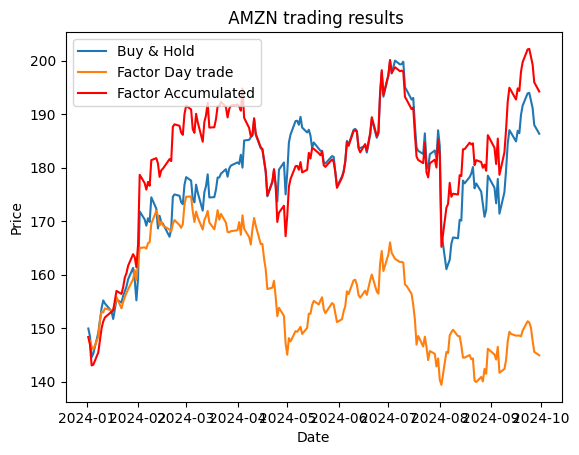

TSLA Tesla us 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,39,26,60,63,188,188,0.526596,0.600000,0.382353,0.00211,0.004564,"[[20230403, -0.0257115702065929], [20230404, 0...","[[20230403, -0.0257115702065929], [20230404, 0..."
test,5,8,26,22,61,61,0.508197,0.384615,0.185185,0.00069,-0.002030,"[[20240102, 0.00663787587971859], [20240103, 0...","[[20240102, 0.00663787587971859], [20240103, 0..."


TSLA Tesla us 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,17,12,82,76,187,187,0.529412,0.586207,0.182796,0.001671,0.002921,"[[20230703, 0.012043835220080235], [20230705, ...","[[20230703, 0.012043835220080235], [20230705, ..."
test,2,3,30,28,63,63,0.507937,0.400000,0.066667,-0.001832,-0.004364,"[[20240401, 0.005392518589998233], [20240402, ...","[[20240401, 0.005392518589998233], [20240402, ..."


TSLA Tesla us 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,13,9,87,78,187,187,0.534759,0.590909,0.142857,0.001499,0.006110,"[[20231002, 0.027735795106409018], [20231003, ...","[[20231002, 0.027735795106409018], [20231003, ..."
test,15,6,22,21,64,64,0.578125,0.714286,0.416667,-0.000595,0.003056,"[[20240701, -0.04397572380857628], [20240702, ...","[[20240701, -0.04397572380857628], [20240702, ..."


188 188 188 188


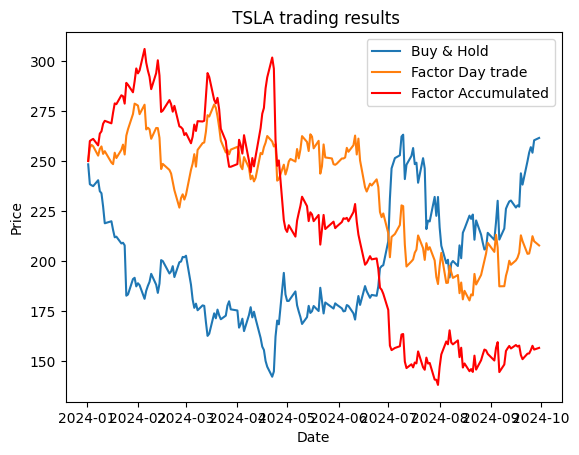

NVDA Nvidia us 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,66,58,33,31,188,188,0.526596,0.532258,0.680412,0.001437,0.001614,"[[20230403, -0.016576393180413665], [20230404,...","[[20230403, -0.016576393180413665], [20230404,..."
test,26,21,4,10,61,61,0.491803,0.553191,0.722222,-0.001663,0.001215,"[[20240102, -0.02185037771099018], [20240103, ...","[[20240102, -0.02185037771099018], [20240103, ..."


NVDA Nvidia us 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,73,62,24,27,186,187,0.521505,0.540741,0.730000,0.000444,0.001062,"[[20230703, 0.002446080391373011], [20230705, ...","[[20230703, 0.002446080391373011], [20230705, ..."
test,22,23,5,13,63,63,0.428571,0.488889,0.628571,-0.002126,-0.001399,"[[20240401, 0.0007087564646340817], [20240402,...","[[20240401, 0.0007087564646340817], [20240402,..."


NVDA Nvidia us 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,72,65,14,17,168,187,0.511905,0.525547,0.808989,0.000014,0.000222,"[[20231002, 0.017079264138087562], [20231003, ...","[[20231002, 0.017079264138087562], [20231003, ..."
test,22,21,9,8,60,64,0.516667,0.511628,0.733333,0.001188,-0.000380,"[[20240701, -0.006722280715963378], [20240702,...","[[20240701, -0.006722280715963378], [20240702,..."


188 188 188 188


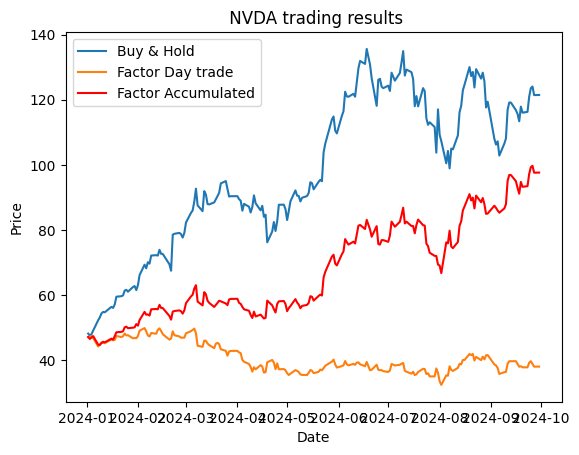

In [16]:
from factor_embd import FactorEmb


for stock in data:
    list_date, list_bnh_rtn, list_daytrade_rtn, list_accumulated_rtn = [], [], [], []
    for date_range in date_ranges:
        env = {
            "stock_id" : stock[0],
            "stock_name" : stock[1],
            "country" : stock[2],
            "start_date" : date_range[0],
            "end_date" : date_range[1],
        }
        print(env['stock_id'], env['stock_name'], env['country'], env['start_date'], env['end_date'])

        factor_embd = FactorEmb(env)

        factor_embd.generate_factors(llm4o)
        factor_embd.expand_factors(llm_factors=llm)
        train_datarange, test_datarange = factor_embd.split_exp()

        re_run = False # 是否重新訓練，True:刪除原有資料

        mode = 1
        df = factor_embd.run_taining(mode, train_datarange, test_datarange, re_run=re_run)
        display(df)


        l_date, l_bnh_rtn, l_daytrade_rtn, l_accumulated_rtn = factor_embd.get_return_list()
        list_date.extend(l_date)
        list_bnh_rtn.extend(l_bnh_rtn)
        list_daytrade_rtn.extend(l_daytrade_rtn)
        list_accumulated_rtn.extend(l_accumulated_rtn)

    print(len(list_date), len(list_bnh_rtn), len(list_daytrade_rtn), len(list_accumulated_rtn))
    list_daytrade_balance = get_balance_list(list_daytrade_rtn, list_bnh_rtn[0])
    list_accumulated_balance = get_balance_list(list_accumulated_rtn, list_bnh_rtn[0])

    dplot = [datetime.strptime(d, '%Y%m%d').date() for d in list_date]
    plt.title(f" {env['stock_id']} trading results")
    plt.plot(dplot, list_bnh_rtn, label="Buy & Hold")  # blue
    plt.plot(dplot, list_daytrade_balance, label="Factor Day trade")  # orange
    plt.plot(dplot, list_accumulated_balance, label="Factor Accumulated", color='red')  # red

    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.show()


## 顯示所有

In [17]:
import os
import json
import pandas as pd

for date_r in  date_ranges:
    env = {
        "start_date": date_r[0],
        "end_date": date_r[1],
    }

    path_out = f"out_stock/Embd_{env['start_date']}_{env['end_date']}/"
    skip_files = {"ac","factors_eng.json", "factors.json", "old_expand", ".DS_Store", "factors.json", "factors1.json", "embeddings.json", "expand.json", "expand1.json", "expand2.json", "clustered_summaries.json"}

    results = []
    index = []

    for folder in os.listdir(path_out):
        if folder in skip_files:
            continue
        folder_path = os.path.join(path_out, folder)
        for file in os.listdir(folder_path):
            if file in skip_files:
                continue
            path = os.path.join(folder_path, file, "result.json")
            with open(path, 'r') as f:
                json_data = json.load(f)

            results.append(json_data['test'])
            index.append(f"{folder}_{file}")

    df = pd.DataFrame(results, index=index)
    selected_columns = ['accuracy', 'precision', 'ev', 'precision_ev',
                        'avail_count', 'tp', 'fp', 'tn', 'fn']  # 替換為您需要的欄位名稱

    # 計算平均值
    average_row = df[['accuracy', 'precision', 'ev', 'precision_ev']].replace('%', '', regex=True).astype(float).mean()
    df['accuracy'] = df['accuracy'].apply(lambda x: f"{x * 100:.2f}%")
    df['precision'] = df['precision'].apply(lambda x: f"{x * 100:.2f}%")
    df_selected = df.loc[:, selected_columns]
    df_sorted = df_selected.sort_index()

    display(df_sorted)
    display(average_row)
    
    

,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
2317_ev,46.43%,46.15%,0.003599,0.003722,56,24,28,2,2
2330_ev,55.36%,48.84%,0.001720,0.000877,56,21,22,10,3
2382_ev,48.21%,48.15%,-0.000266,-0.000734,56,26,28,1,1
2454_ev,53.57%,60.00%,0.003906,0.018223,56,3,2,27,24
3231_ev,42.86%,42.59%,-0.003028,-0.003603,56,23,31,1,1
AAPL_ev,52.46%,48.39%,0.000194,0.000506,61,15,16,17,13
AMZN_ev,57.38%,60.00%,0.001925,0.002241,61,30,20,5,6
GOOGL_ev,47.54%,62.50%,0.000792,0.003307,61,10,6,19,26
MSFT_ev,45.90%,0.00%,-0.001251,0.000000,61,0,2,28,31
NVDA_ev,49.18%,55.32%,-0.001663,0.001215,61,26,21,4,10


accuracy        0.499734
precision       0.464000
ev              0.000602
precision_ev    0.002157
dtype: float64

,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
2317_ev,52.46%,50.00%,0.004030,0.005859,61,19,19,13,10
2330_ev,57.38%,55.56%,0.003375,0.003820,61,20,16,15,10
2382_ev,42.62%,42.86%,-0.001431,-0.001874,61,24,32,2,3
2454_ev,49.18%,46.94%,0.002639,0.001166,61,23,26,7,5
3231_ev,32.79%,27.78%,-0.004040,-0.005881,61,15,39,5,2
AAPL_ev,50.79%,47.06%,-0.000845,-0.000435,63,24,27,8,4
AMZN_ev,49.21%,50.94%,-0.000629,-0.000498,63,27,26,4,6
GOOGL_ev,57.14%,66.67%,0.001097,0.002664,63,32,16,4,11
MSFT_ev,53.97%,64.52%,0.000509,0.000567,63,20,11,14,18
NVDA_ev,42.86%,48.89%,-0.002126,-0.001399,63,22,23,5,13


accuracy        0.490171
precision       0.492003
ev              0.000068
precision_ev   -0.000034
dtype: float64

,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
2317_ev,47.62%,44.23%,0.002343,0.000416,63,23,29,7,4
2330_ev,53.97%,52.17%,0.004052,0.003397,63,24,22,10,7
2382_ev,49.21%,0.00%,0.002566,0.000000,63,0,1,31,31
2454_ev,50.79%,44.44%,0.002864,0.006866,63,8,10,24,21
3231_ev,49.21%,23.81%,-0.001645,-0.006698,63,5,16,26,16
AAPL_ev,50.00%,56.52%,-0.001011,0.000426,64,26,20,6,12
AMZN_ev,39.68%,38.89%,-0.001530,-0.001977,63,21,33,4,5
GOOGL_ev,55.56%,52.08%,0.000878,-0.000976,63,25,23,10,5
MSFT_ev,54.84%,53.12%,0.000706,-0.000620,62,17,15,17,13
NVDA_ev,51.67%,51.16%,0.001188,-0.000380,60,22,21,9,8


accuracy        0.509409
precision       0.443517
ev              0.000892
precision_ev    0.000319
dtype: float64

# Factor Evaluate Accumulate(Over night)

2330 台積電 tw 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,46,49,34,56,185,185,0.432432,0.484211,0.450980,0.000144,0.001884,"[[20230406, 0.0], [20230407, 0.009433962264150..."
test,16,19,10,11,56,56,0.464286,0.457143,0.592593,0.000367,0.002111,"[[20240102, 0.005084745762711864], [20240103, ..."


2330 台積電 tw 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,86,73,12,11,182,182,0.538462,0.540881,0.886598,0.002285,0.002723,"[[20230703, 0.0017301038062283738], [20230704,..."
test,27,22,6,6,61,61,0.540984,0.551020,0.818182,0.003897,0.004022,"[[20240401, -0.016602809706257982], [20240402,..."


2330 台積電 tw 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,99,67,5,9,180,180,0.577778,0.596386,0.916667,0.003853,0.004605,"[[20231002, -0.005660377358490566], [20231003,..."
test,27,21,5,10,63,63,0.507937,0.562500,0.729730,-0.000208,0.002333,"[[20240701, 0.0], [20240702, -0.00103305785123..."


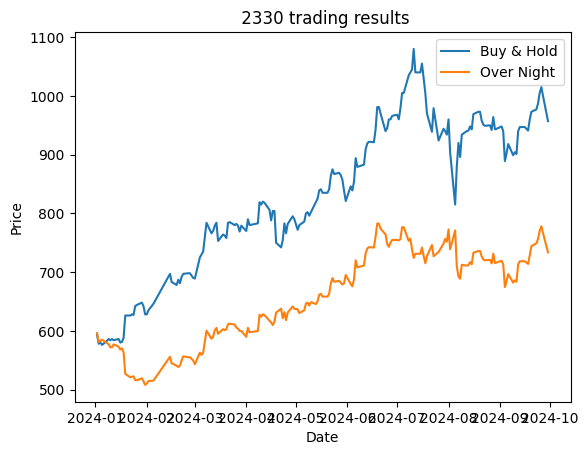

2317 鴻海 tw 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,54,89,10,32,185,185,0.345946,0.377622,0.627907,0.000006,0.000020,"[[20230406, -0.009569377990430622], [20230407,..."
test,23,24,3,6,56,56,0.464286,0.489362,0.793103,0.007105,0.008516,"[[20240102, 0.004784688995215311], [20240103, ..."


2317 鴻海 tw 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,56,77,14,35,182,182,0.384615,0.421053,0.615385,0.001935,0.002904,"[[20230703, -0.008771929824561403], [20230704,..."
test,26,22,7,6,61,61,0.540984,0.541667,0.812500,0.006392,0.007862,"[[20240401, -0.0033112582781456954], [20240402..."


2317 鴻海 tw 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,73,73,10,24,180,180,0.461111,0.500000,0.752577,0.004733,0.005891,"[[20231002, 0.004807692307692308], [20231003, ..."
test,26,21,7,9,63,63,0.523810,0.553191,0.742857,-0.001507,-0.000574,"[[20240701, 0.004651162790697674], [20240702, ..."


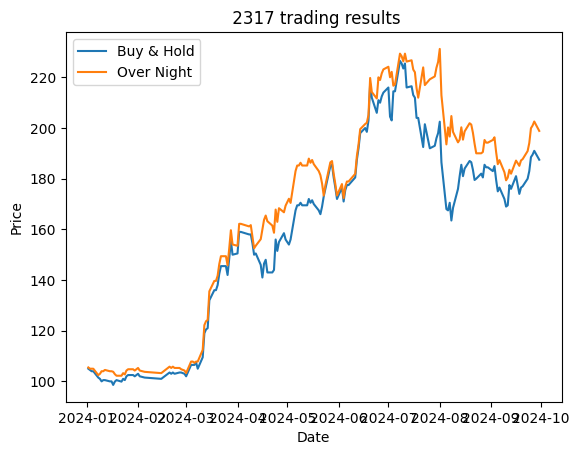

2454 聯發科 tw 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,84,74,13,14,185,185,0.524324,0.531646,0.857143,0.002249,0.003510,"[[20230406, 0.027131782945736434], [20230407, ..."
test,25,25,4,2,56,56,0.517857,0.500000,0.925926,0.006139,0.005014,"[[20240102, 0.028712871287128714], [20240103, ..."


2454 聯發科 tw 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,87,73,16,6,182,182,0.565934,0.543750,0.935484,0.005041,0.005203,"[[20230703, -0.001445086705202312], [20230704,..."
test,24,25,4,8,61,61,0.459016,0.489796,0.750000,0.003363,0.004417,"[[20240401, -0.025210084033613446], [20240402,..."


2454 聯發科 tw 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,71,62,25,22,180,180,0.533333,0.533835,0.763441,0.005173,0.006407,"[[20231002, -0.002677376171352075], [20231003,..."
test,16,18,14,15,63,63,0.476190,0.470588,0.516129,0.001209,0.003222,"[[20240701, 0.0071174377224199285], [20240702,..."


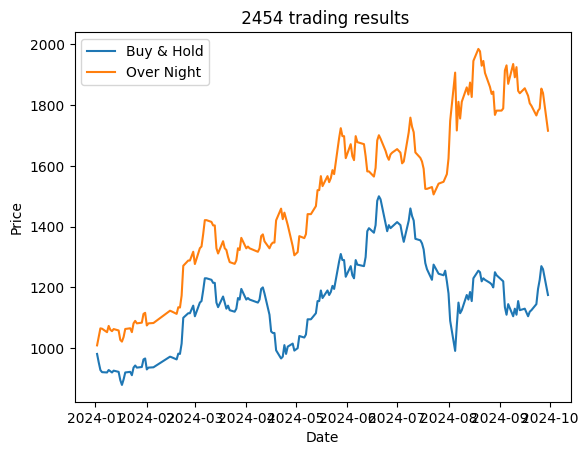

2382 廣達 tw 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,91,71,12,11,185,185,0.556757,0.561728,0.892157,0.004176,0.005665,"[[20230406, 0.00897867564534244], [20230407, -..."
test,29,24,1,2,56,56,0.535714,0.547170,0.935484,0.005771,0.006529,"[[20240102, -0.0467706013363029], [20240103, 0..."


2382 廣達 tw 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,83,77,7,15,182,182,0.494505,0.518750,0.846939,0.003174,0.004667,"[[20230703, 0.035483870967741936], [20230704, ..."
test,27,31,1,2,61,61,0.459016,0.465517,0.931034,-0.000627,-0.000542,"[[20240401, -0.04074702886247878], [20240402, ..."


2382 廣達 tw 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,88,81,4,7,180,180,0.511111,0.52071,0.926316,0.001636,0.002025,"[[20231002, 0.03877551020408163], [20231003, -..."
test,24,24,6,9,63,63,0.476190,0.50000,0.727273,-0.000607,0.002837,"[[20240701, -0.01437699680511182], [20240702, ..."


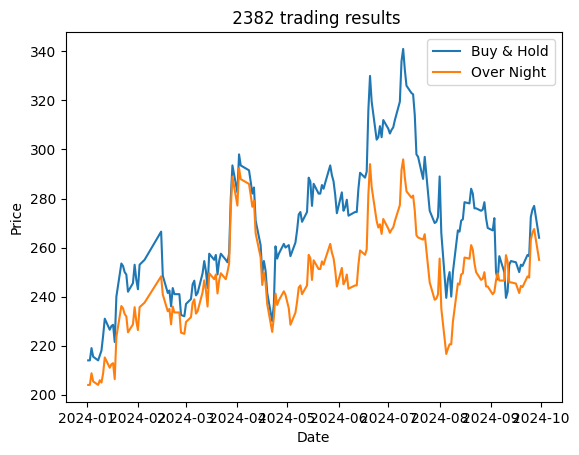

3231 緯創 tw 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,94,81,5,5,185,185,0.535135,0.537143,0.949495,0.006854,0.007567,"[[20230406, 0.0], [20230407, -0.01932367149758..."
test,25,28,1,2,56,56,0.464286,0.471698,0.925926,0.003710,0.004169,"[[20240102, -0.04969574036511148], [20240103, ..."


3231 緯創 tw 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,73,74,18,17,182,182,0.500000,0.496599,0.811111,0.003169,0.003763,"[[20230703, 0.02243589743589753], [20230704, 0..."
test,21,28,6,6,61,61,0.442623,0.428571,0.777778,-0.001916,-0.003168,"[[20240401, -0.03543307086614173], [20240402, ..."


3231 緯創 tw 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,72,77,17,14,180,180,0.494444,0.483221,0.837209,0.001946,0.001098,"[[20231002, 0.0673076923076923], [20231003, -0..."
test,22,29,7,5,63,63,0.460317,0.431373,0.814815,0.001548,0.001053,"[[20240701, -0.009389671361502348], [20240702,..."


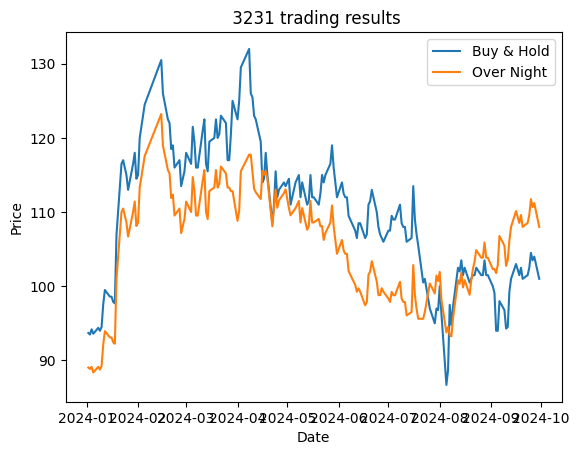

AAPL Apple Inc. us 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,39,30,48,71,188,188,0.462766,0.565217,0.354545,-0.000026,0.001944,"[[20230403, 0.011566323735313673], [20230404, ..."
test,8,10,28,15,61,61,0.590164,0.444444,0.347826,0.000573,-0.001454,"[[20240102, -0.008068394336094145], [20240103,..."


AAPL Apple Inc. us 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,49,56,44,38,187,187,0.497326,0.466667,0.563218,-0.000006,-0.000276,"[[20230703, -0.00681184848797602], [20230705, ..."
test,25,18,11,9,63,63,0.571429,0.581395,0.735294,0.000529,0.000246,"[[20240401, 0.00677609673462233], [20240402, 0..."


AAPL Apple Inc. us 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,53,47,54,33,187,187,0.572193,0.530000,0.616279,0.001484,0.000949,"[[20231002, 0.014776311178600638], [20231003, ..."
test,24,15,11,14,64,64,0.546875,0.615385,0.631579,-0.001507,0.000905,"[[20240701, 0.021971804422650745], [20240702, ..."


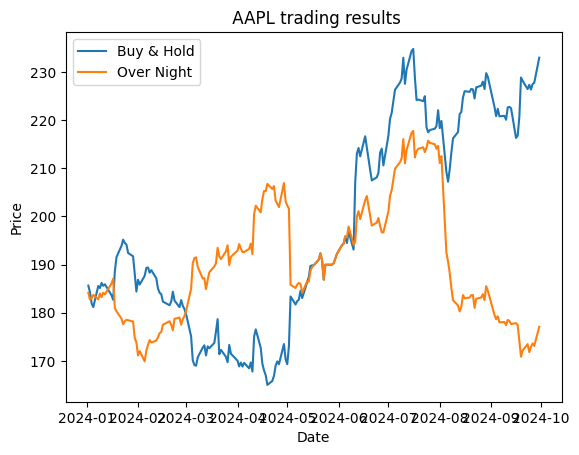

GOOGL Google us 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,41,29,53,65,188,188,0.500000,0.585714,0.386792,0.000274,0.004369,"[[20230403, 0.019240160171891774], [20230404, ..."
test,5,8,20,28,61,61,0.409836,0.384615,0.151515,0.000527,0.000122,"[[20240102, 0.002742692168892269], [20240103, ..."


GOOGL Google us 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,40,32,52,63,187,187,0.491979,0.555556,0.388350,0.000597,0.003587,"[[20230703, 0.005535055350553596], [20230705, ..."
test,9,12,12,30,63,63,0.333333,0.428571,0.230769,-0.004866,-0.006032,"[[20240401, -0.03185347401951033], [20240402, ..."


GOOGL Google us 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,28,29,46,84,187,187,0.395722,0.491228,0.25,-0.000787,0.003114,"[[20231002, 0.022559256154256378], [20231003, ..."
test,9,15,19,21,64,64,0.437500,0.375000,0.30,-0.000947,-0.003637,"[[20240701, -0.00021854340818440714], [2024070..."


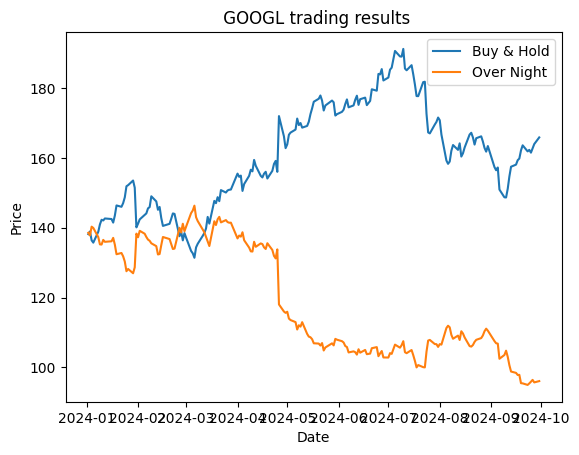

MSFT Microsoft us 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,64,44,34,46,188,188,0.521277,0.592593,0.581818,-0.000163,0.001422,"[[20230403, 0.002478012006142805], [20230404, ..."
test,23,26,8,4,61,61,0.508197,0.469388,0.851852,0.000969,0.000348,"[[20240102, -0.007997646177713607], [20240103,..."


MSFT Microsoft us 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,80,59,21,27,187,187,0.540107,0.575540,0.747664,0.000857,0.001402,"[[20230703, 0.003537840148589253], [20230705, ..."
test,28,19,6,10,63,63,0.539683,0.595745,0.736842,0.000179,0.000690,"[[20240401, -0.0014624366080905876], [20240402..."


MSFT Microsoft us 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,81,64,20,22,187,187,0.540107,0.558621,0.786408,0.000817,0.001066,"[[20231002, 0.01745288984444176], [20231003, -..."
test,18,22,12,12,64,64,0.468750,0.450000,0.600000,0.000480,-0.000061,"[[20240701, 0.01798689430749341], [20240702, 0..."


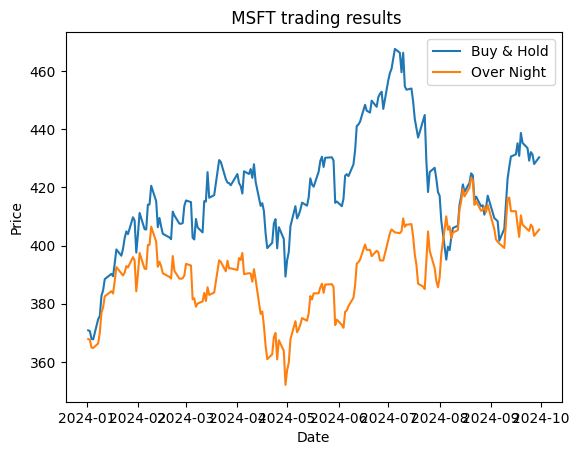

AMZN Amazon inc. us 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,50,52,37,49,188,188,0.462766,0.490196,0.505051,-0.000526,0.000618,"[[20230403, -0.0010752688172042957], [20230404..."
test,20,16,16,9,61,61,0.590164,0.555556,0.689655,0.001954,0.000938,"[[20240102, -0.010624257621749936], [20240103,..."


AMZN Amazon inc. us 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,71,58,28,30,187,187,0.529412,0.550388,0.702970,0.001102,0.002270,"[[20230703, -0.004586454670539629], [20230705,..."
test,28,23,4,8,63,63,0.507937,0.549020,0.777778,0.000365,0.001644,"[[20240401, 0.0009956302892859495], [20240402,..."


AMZN Amazon inc. us 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,79,53,25,29,186,187,0.559140,0.598485,0.731481,0.001722,0.003157,"[[20231002, -0.017127592708988112], [20231003,..."
test,20,27,9,8,64,64,0.453125,0.425532,0.714286,0.001559,0.001156,"[[20240701, -0.019174117525453404], [20240702,..."


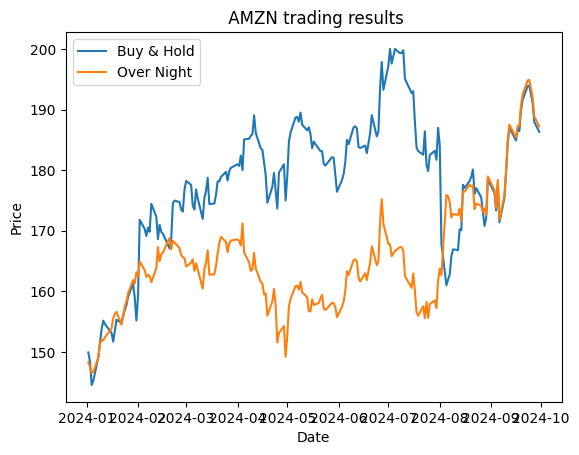

TSLA Tesla us 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,11,6,79,92,188,188,0.478723,0.647059,0.106796,-0.000970,0.005947,"[[20230403, 0.0257115702065929], [20230404, 0...."
test,0,3,30,28,61,61,0.491803,0.000000,0.000000,0.002825,0.000000,"[[20240102, 0.00663787587971859], [20240103, 0..."


TSLA Tesla us 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,22,24,70,71,187,187,0.491979,0.478261,0.236559,0.000823,-0.000616,"[[20230703, 0.012043835220080235], [20230705, ..."
test,0,3,31,29,63,63,0.492063,0.000000,0.000000,-0.005581,0.000000,"[[20240401, -0.005392518589998233], [20240402,..."


TSLA Tesla us 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,9,17,78,83,187,187,0.465241,0.346154,0.097826,-0.001627,-0.005993,"[[20231002, 0.027735795106409018], [20231003, ..."
test,7,9,24,24,64,64,0.484375,0.437500,0.225806,0.000582,0.000976,"[[20240701, -0.04397572380857628], [20240702, ..."


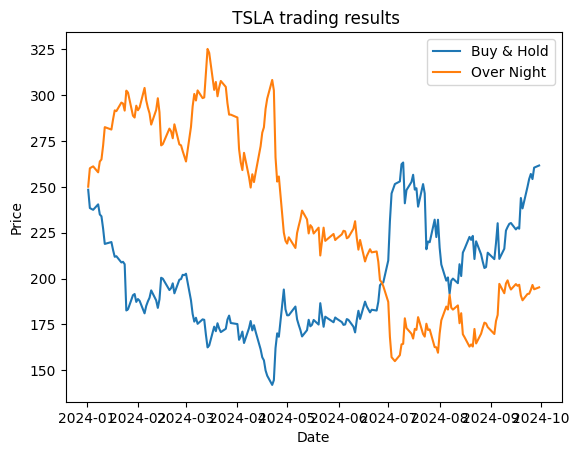

NVDA Nvidia us 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,86,53,22,26,187,188,0.577540,0.618705,0.767857,0.005050,0.006897,"[[20230403, -0.016576393180413665], [20230404,..."
test,33,18,4,6,61,61,0.606557,0.647059,0.846154,0.005979,0.008149,"[[20240102, -0.02185037771099018], [20240103, ..."


NVDA Nvidia us 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,89,53,21,24,187,187,0.588235,0.626761,0.787611,0.003777,0.005260,"[[20230703, 0.002446080391373011], [20230705, ..."
test,25,22,7,9,63,63,0.507937,0.531915,0.735294,0.004892,0.005984,"[[20240401, 0.0007087564646340817], [20240402,..."


NVDA Nvidia us 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,85,54,20,27,186,187,0.564516,0.611511,0.758929,0.004599,0.007082,"[[20231002, 0.017079264138087562], [20231003, ..."
test,22,18,10,14,64,64,0.500000,0.550000,0.611111,0.001955,0.007397,"[[20240701, -0.006722280715963378], [20240702,..."


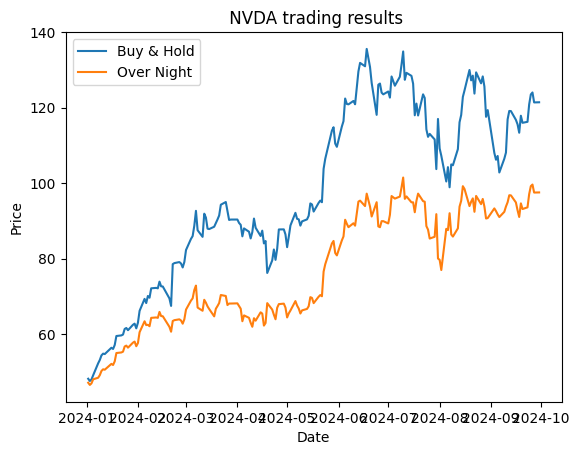

In [4]:
from factor_eval_accu import EvalAccumulated


for stock in data:
    list_date, list_bnh_rtn, list_stag_rtn  = [], [], []
    for date_range in date_ranges:
        env = {
            "stock_id" : stock[0],
            "stock_name" : stock[1],
            "country" : stock[2],
            "start_date" : date_range[0],
            "end_date" : date_range[1],
        }
        print(env['stock_id'], env['stock_name'], env['country'], env['start_date'], env['end_date'])

        factor_accu = EvalAccumulated(env)

        factor_accu.generate_factors(llm4o)
        factor_accu.expand_factors(llm_factors=llm)
        train_datarange, test_datarange = factor_accu.split_exp()

        re_run = False # 是否重新訓練，True:刪除原有資料

        mode = 1
        df = factor_accu.run_taining(mode, train_datarange, test_datarange, re_run=re_run)
        display(df)


        l_date, l_bnh_rtn, l_stag_rtn = factor_accu.get_return_list()
        # print(len(l_date), len(l_bnh_rtn), len(l_stag_rtn))
        list_date.extend(l_date)
        list_bnh_rtn.extend(l_bnh_rtn)
        list_stag_rtn.extend(l_stag_rtn)
        # print(len(list_date), len(list_bnh_rtn), len(list_stag_rtn))

    # print(len(list_date), len(list_bnh_rtn), len(list_stag_rtn))
    list_stag_balance = get_balance_list(list_stag_rtn, list_bnh_rtn[0])

    dplot = [datetime.strptime(d, '%Y%m%d').date() for d in list_date]
    plt.title(f" {env['stock_id']} trading results")
    plt.plot(dplot, list_bnh_rtn, label="Buy & Hold")  # blue
    plt.plot(dplot, list_stag_balance, label="Over Night")  # orange

    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.show()


In [8]:
import pandas as pd
from factor_eval_accu import EvalAccumulated

stock_results = []
index = []
for stock in data:
    # print(stock, "Test Result")
    for date_range in date_ranges:
        env = {
            "stock_id" : stock[0],
            "stock_name" : stock[1],
            "country" : stock[2],
            "start_date" : date_range[0],
            "end_date" : date_range[1],
        }
        
        factor_accu = EvalAccumulated(env)
        result = factor_accu.get_result(1)
        index.append(f"{stock[0]} -> {date_range[0]} ~ {date_range[1]}")
        
        stock_results.append(result["test"])
df_stock_results = pd.DataFrame(stock_results, index=index)
selected_columns = ['accuracy', 'precision', 'ev', 'precision_ev',
                    'avail_count', 'tp', 'fp', 'tn', 'fn']  # 替換為您需要的欄位名稱
df_selected = df_stock_results.loc[:, selected_columns]


columns_to_average = ['accuracy', 'precision', 'ev', 'precision_ev']
averages = df_selected[columns_to_average].replace('%', '', regex=True).astype(float).mean()

# 建立平均值作為新的 DataFrame 行
average_row = pd.DataFrame(averages).T
average_row.index = ['平均值']

# 將平均值行添加到選定的 DataFrame
df_selected_with_avg = pd.concat([df_selected, average_row])
df_selected_with_avg['accuracy'] = df_selected_with_avg['accuracy'].apply(lambda x: f"{x * 100:.2f}%")
df_selected_with_avg['precision'] = df_selected_with_avg['precision'].apply(lambda x: f"{x * 100:.2f}%")

# 顯示結果
display(df_selected_with_avg)
    

,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
2330 -> 20230401 ~ 20240331,46.43%,45.71%,0.000367,0.002111,56.0,16.0,19.0,10.0,11.0
2330 -> 20230701 ~ 20240630,54.10%,55.10%,0.003897,0.004022,61.0,27.0,22.0,6.0,6.0
2330 -> 20231001 ~ 20240930,50.79%,56.25%,-0.000208,0.002333,63.0,27.0,21.0,5.0,10.0
2317 -> 20230401 ~ 20240331,46.43%,48.94%,0.007105,0.008516,56.0,23.0,24.0,3.0,6.0
2317 -> 20230701 ~ 20240630,54.10%,54.17%,0.006392,0.007862,61.0,26.0,22.0,7.0,6.0
2317 -> 20231001 ~ 20240930,52.38%,55.32%,-0.001507,-0.000574,63.0,26.0,21.0,7.0,9.0
2454 -> 20230401 ~ 20240331,51.79%,50.00%,0.006139,0.005014,56.0,25.0,25.0,4.0,2.0
2454 -> 20230701 ~ 20240630,45.90%,48.98%,0.003363,0.004417,61.0,24.0,25.0,4.0,8.0
2454 -> 20231001 ~ 20240930,47.62%,47.06%,0.001209,0.003222,63.0,16.0,18.0,14.0,15.0
2382 -> 20230401 ~ 20240331,53.57%,54.72%,0.005771,0.006529,56.0,29.0,24.0,1.0,2.0


# Embd Overnight

2330 台積電 tw 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,70,70,25,20,185,185,0.513514,0.500000,0.777778,0.001280,0.001118,"[[20230406, 0.0], [20230407, 0.001886792452830..."
test,26,20,5,5,56,56,0.553571,0.565217,0.838710,0.003855,0.004824,"[[20240102, 0.005084745762711864], [20240103, ..."


2330 台積電 tw 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,76,71,16,19,182,182,0.505495,0.517007,0.800000,0.001863,0.002287,"[[20230703, -0.0017301038062283738], [20230704..."
test,27,20,8,6,61,61,0.573770,0.574468,0.818182,0.004295,0.004246,"[[20240401, -0.016602809706257982], [20240402,..."


2330 台積電 tw 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,80,62,21,17,180,180,0.561111,0.563380,0.824742,0.003611,0.003954,"[[20231002, 0.005660377358490566], [20231003, ..."
test,24,20,6,13,63,63,0.476190,0.545455,0.648649,0.000794,0.002431,"[[20240701, 0.0], [20240702, -0.00103305785123..."


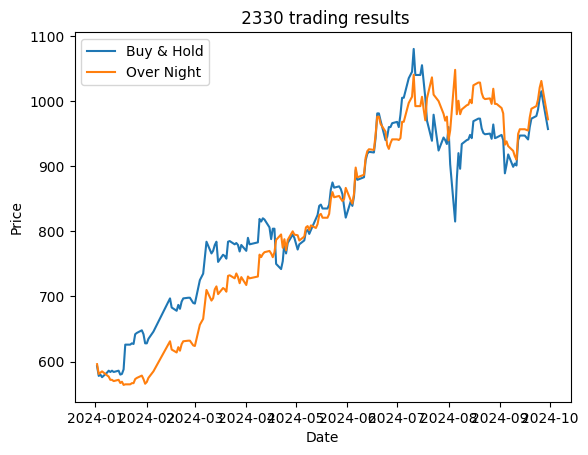

2317 鴻海 tw 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,55,84,15,31,185,185,0.378378,0.395683,0.639535,0.000919,0.000877,"[[20230406, -0.009569377990430622], [20230407,..."
test,23,26,1,6,56,56,0.428571,0.469388,0.793103,0.006753,0.007946,"[[20240102, 0.004784688995215311], [20240103, ..."


2317 鴻海 tw 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,56,77,18,31,182,182,0.406593,0.421053,0.643678,0.002384,0.003095,"[[20230703, -0.008771929824561403], [20230704,..."
test,32,21,4,4,61,61,0.590164,0.603774,0.888889,0.008642,0.009647,"[[20240401, -0.0033112582781456954], [20240402..."


2317 鴻海 tw 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,78,74,9,19,180,180,0.483333,0.513158,0.804124,0.005276,0.006099,"[[20231002, 0.004807692307692308], [20231003, ..."
test,26,25,4,8,63,63,0.476190,0.509804,0.764706,-0.004450,-0.002355,"[[20240701, 0.004651162790697674], [20240702, ..."


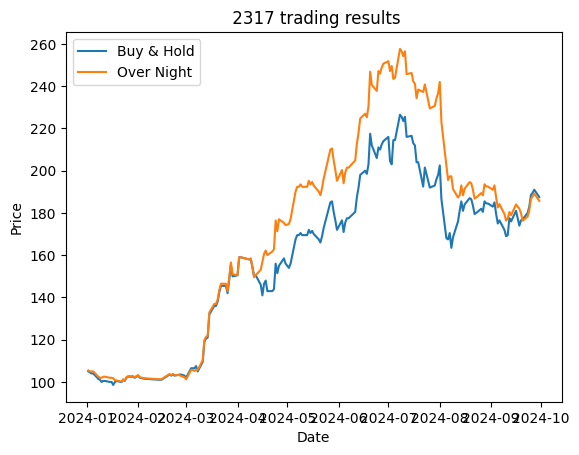

2454 聯發科 tw 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,47,56,41,41,185,185,0.475676,0.456311,0.534091,0.002543,0.001751,"[[20230406, -0.027131782945736434], [20230407,..."
test,17,21,9,9,56,56,0.464286,0.447368,0.653846,0.003773,0.004751,"[[20240102, 0.028712871287128714], [20240103, ..."


2454 聯發科 tw 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,84,78,14,6,182,182,0.538462,0.518519,0.933333,0.004564,0.004660,"[[20230703, -0.001445086705202312], [20230704,..."
test,23,24,5,9,61,61,0.459016,0.489362,0.718750,0.003365,0.004836,"[[20240401, -0.025210084033613446], [20240402,..."


2454 聯發科 tw 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,83,73,12,12,180,180,0.527778,0.532051,0.873684,0.005020,0.005519,"[[20231002, -0.002677376171352075], [20231003,..."
test,19,23,7,14,63,63,0.412698,0.452381,0.575758,-0.000521,0.002659,"[[20240701, 0.0071174377224199285], [20240702,..."


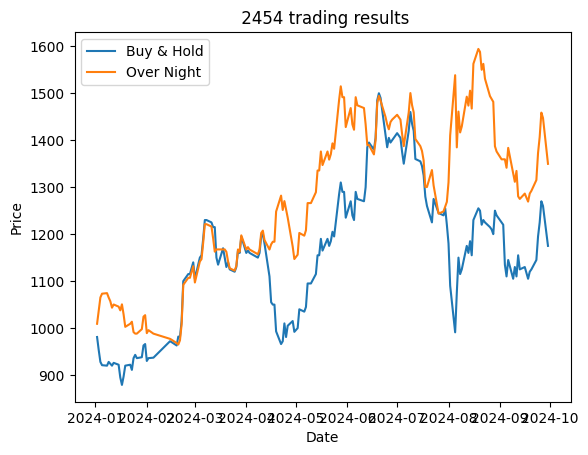

2382 廣達 tw 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,93,74,10,8,185,185,0.556757,0.556886,0.920792,0.006704,0.006658,"[[20230406, 0.00897867564534244], [20230407, -..."
test,29,25,0,2,56,56,0.517857,0.537037,0.935484,0.005491,0.006336,"[[20240102, -0.0467706013363029], [20240103, 0..."


2382 廣達 tw 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,79,68,17,18,182,182,0.527473,0.537415,0.814433,0.004331,0.005067,"[[20230703, 0.035483870967741936], [20230704, ..."
test,27,29,1,4,61,61,0.459016,0.482143,0.870968,0.000615,0.001253,"[[20240401, -0.04074702886247878], [20240402, ..."


2382 廣達 tw 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,83,80,5,12,180,180,0.488889,0.509202,0.873684,0.000559,0.001097,"[[20231002, 0.03877551020408163], [20231003, -..."
test,23,23,8,9,63,63,0.492063,0.500000,0.718750,0.002007,0.003660,"[[20240701, -0.01437699680511182], [20240702, ..."


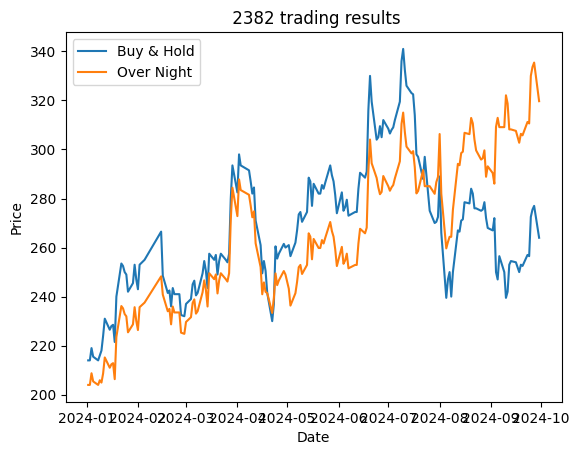

3231 緯創 tw 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,93,83,4,5,185,185,0.524324,0.528409,0.948980,0.006170,0.006592,"[[20230406, 0.0], [20230407, -0.01932367149758..."
test,26,28,0,2,56,56,0.464286,0.481481,0.928571,0.003824,0.004269,"[[20240102, -0.04969574036511148], [20240103, ..."


3231 緯創 tw 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,84,87,6,5,182,182,0.494505,0.491228,0.943820,0.002956,0.003548,"[[20230703, 0.02243589743589753], [20230704, 0..."
test,23,33,4,1,61,61,0.442623,0.410714,0.958333,-0.002020,-0.003323,"[[20240401, -0.03543307086614173], [20240402, ..."


3231 緯創 tw 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,75,89,11,5,180,180,0.477778,0.457317,0.937500,0.001342,0.000574,"[[20231002, 0.0673076923076923], [20231003, -0..."
test,24,31,6,2,63,63,0.476190,0.436364,0.923077,-0.000545,-0.000639,"[[20240701, 0.009389671361502348], [20240702, ..."


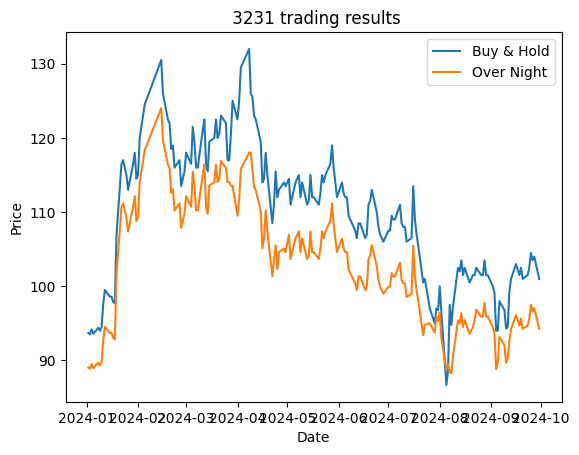

AAPL Apple Inc. us 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,69,60,32,27,188,188,0.537234,0.534884,0.71875,0.001318,0.001419,"[[20230403, 0.011566323735313673], [20230404, ..."
test,13,17,19,12,61,61,0.524590,0.433333,0.52000,0.000044,0.000403,"[[20240102, -0.008068394336094145], [20240103,..."


AAPL Apple Inc. us 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,56,54,44,33,187,187,0.534759,0.509091,0.629213,0.000650,0.000843,"[[20230703, -0.00681184848797602], [20230705, ..."
test,26,19,12,6,63,63,0.603175,0.577778,0.812500,0.001648,0.001170,"[[20240401, 0.00677609673462233], [20240402, 0..."


AAPL Apple Inc. us 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,83,56,28,20,187,187,0.593583,0.597122,0.805825,0.002021,0.002484,"[[20231002, 0.014776311178600638], [20231003, ..."
test,24,21,8,11,64,64,0.500000,0.533333,0.685714,-0.002724,-0.000756,"[[20240701, 0.021971804422650745], [20240702, ..."


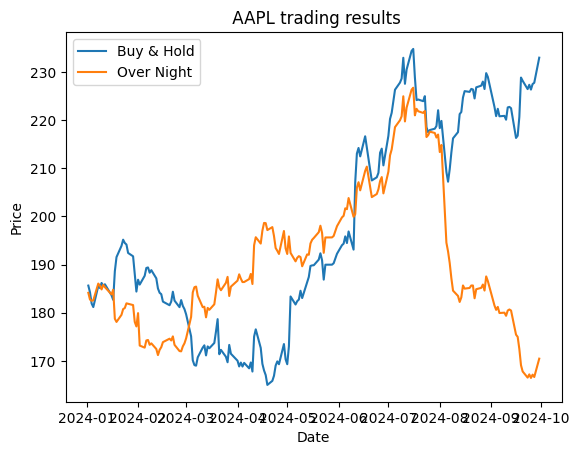

GOOGL Google us 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,44,40,51,53,188,188,0.505319,0.523810,0.453608,0.001667,0.003067,"[[20230403, 0.019240160171891774], [20230404, ..."
test,6,7,21,27,61,61,0.442623,0.461538,0.181818,0.000994,0.001693,"[[20240102, 0.002742692168892269], [20240103, ..."


GOOGL Google us 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,91,62,20,14,187,187,0.593583,0.594771,0.866667,0.002103,0.002653,"[[20230703, 0.005535055350553596], [20230705, ..."
test,25,22,8,8,63,63,0.523810,0.531915,0.757576,0.000562,0.001137,"[[20240401, 0.03185347401951033], [20240402, -..."


GOOGL Google us 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,86,60,22,19,187,187,0.577540,0.589041,0.819048,0.001626,0.002413,"[[20231002, 0.022559256154256378], [20231003, ..."
test,19,28,10,7,64,64,0.453125,0.404255,0.730769,-0.001841,-0.003644,"[[20240701, -0.00021854340818440714], [2024070..."


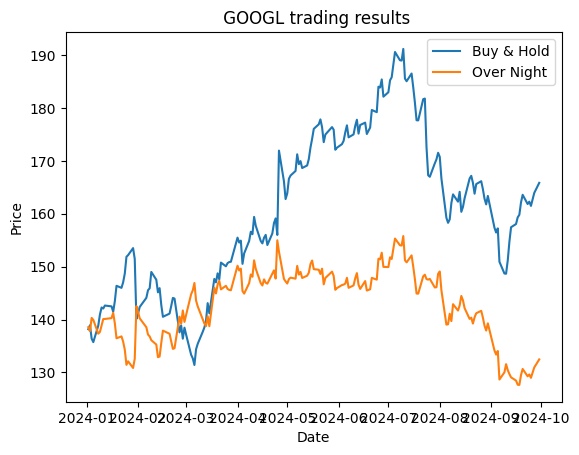

MSFT Microsoft us 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,75,68,22,21,186,188,0.521505,0.524476,0.781250,0.001567,0.001330,"[[20230403, 0.002478012006142805], [20230404, ..."
test,26,28,4,3,61,61,0.491803,0.481481,0.896552,0.001159,0.001248,"[[20240102, -0.007997646177713607], [20240103,..."


MSFT Microsoft us 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,74,49,29,35,187,187,0.550802,0.601626,0.678899,0.001305,0.002099,"[[20230703, 0.003537840148589253], [20230705, ..."
test,31,18,7,7,63,63,0.603175,0.632653,0.815789,0.001814,0.001581,"[[20240401, -0.0014624366080905876], [20240402..."


MSFT Microsoft us 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,52,34,56,45,187,187,0.577540,0.604651,0.536082,0.000629,0.001680,"[[20231002, -0.01745288984444176], [20231003, ..."
test,11,15,20,18,64,64,0.484375,0.423077,0.379310,0.000722,0.000029,"[[20240701, -0.01798689430749341], [20240702, ..."


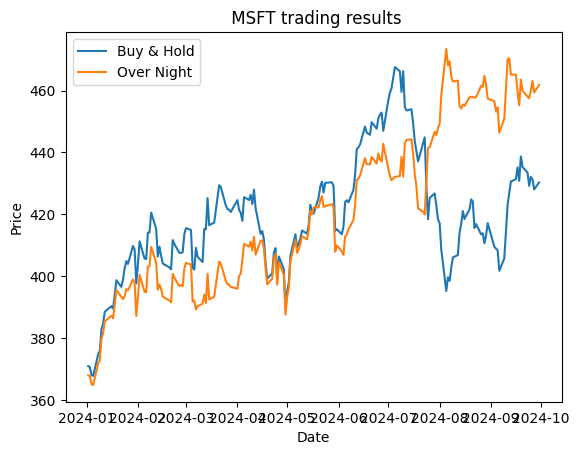

AMZN Amazon inc. us 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,92,69,15,12,188,188,0.569149,0.571429,0.884615,0.002023,0.002474,"[[20230403, 0.0010752688172042957], [20230404,..."
test,29,18,10,4,61,61,0.639344,0.617021,0.878788,0.004010,0.004711,"[[20240102, -0.010624257621749936], [20240103,..."


AMZN Amazon inc. us 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,91,73,13,10,187,187,0.556150,0.554878,0.900990,0.001934,0.002222,"[[20230703, -0.004586454670539629], [20230705,..."
test,29,28,2,4,63,63,0.492063,0.508772,0.878788,0.000317,0.001202,"[[20240401, 0.0009956302892859495], [20240402,..."


AMZN Amazon inc. us 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,94,73,9,11,187,187,0.550802,0.562874,0.895238,0.002319,0.002729,"[[20231002, 0.017127592708988112], [20231003, ..."
test,27,29,6,2,64,64,0.515625,0.482143,0.931034,0.000081,0.000563,"[[20240701, 0.019174117525453404], [20240702, ..."


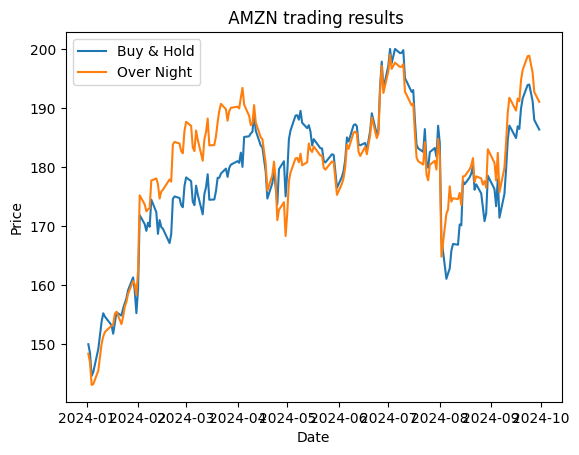

TSLA Tesla us 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,60,38,47,43,188,188,0.569149,0.612245,0.582524,0.006324,0.005690,"[[20230403, -0.0257115702065929], [20230404, 0..."
test,5,11,21,24,61,61,0.426230,0.312500,0.172414,-0.001035,-0.004742,"[[20240102, 0.00663787587971859], [20240103, 0..."


TSLA Tesla us 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,11,12,83,81,187,187,0.502674,0.478261,0.119565,0.002256,0.001065,"[[20230703, 0.012043835220080235], [20230705, ..."
test,1,4,29,29,63,63,0.476190,0.200000,0.033333,-0.005993,-0.032152,"[[20240401, -0.005392518589998233], [20240402,..."


TSLA Tesla us 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,6,10,85,86,187,187,0.486631,0.375000,0.065217,0.000567,-0.006411,"[[20231002, 0.027735795106409018], [20231003, ..."
test,10,9,22,23,64,64,0.500000,0.526316,0.303030,-0.001820,-0.001884,"[[20240701, -0.04397572380857628], [20240702, ..."


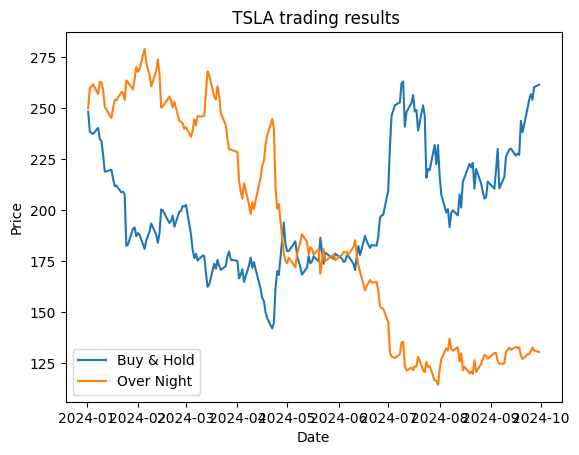

NVDA Nvidia us 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,74,45,34,30,183,188,0.590164,0.621849,0.711538,0.006466,0.008818,"[[20230403, -0.016576393180413665], [20230404,..."
test,25,20,9,5,59,61,0.576271,0.555556,0.833333,0.003102,0.003243,"[[20240102, -0.02185037771099018], [20240103, ..."


NVDA Nvidia us 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,80,51,30,26,187,187,0.588235,0.610687,0.754717,0.004247,0.006177,"[[20230703, 0.002446080391373011], [20230705, ..."
test,24,21,7,11,63,63,0.492063,0.533333,0.685714,0.004708,0.007009,"[[20240401, 0.0007087564646340817], [20240402,..."


NVDA Nvidia us 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,85,55,19,21,180,187,0.577778,0.607143,0.801887,0.003484,0.005710,"[[20231002, 0.017079264138087562], [20231003, ..."
test,25,20,7,12,64,64,0.500000,0.555556,0.675676,0.003971,0.008641,"[[20240701, -0.006722280715963378], [20240702,..."


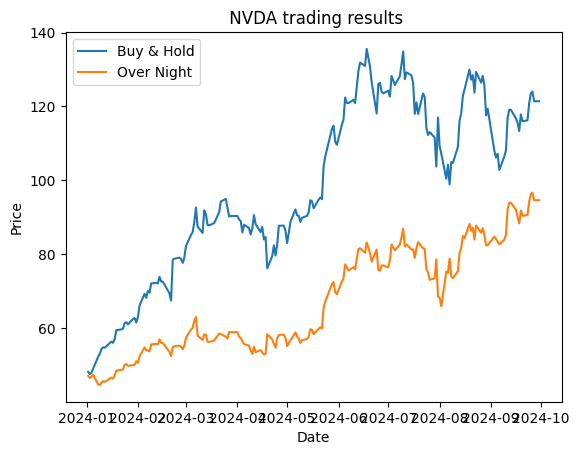

In [8]:
from factor_embdon import FactorEmbOverNight


for stock in data:
    list_date, list_bnh_rtn, list_stag_rtn  = [], [], []
    for date_range in date_ranges:
        env = {
            "stock_id" : stock[0],
            "stock_name" : stock[1],
            "country" : stock[2],
            "start_date" : date_range[0],
            "end_date" : date_range[1],
        }
        print(env['stock_id'], env['stock_name'], env['country'], env['start_date'], env['end_date'])

        factor_embdon = FactorEmbOverNight(env)

        factor_embdon.generate_factors(llm4o)
        factor_embdon.expand_factors(llm_factors=llm)
        train_datarange, test_datarange = factor_embdon.split_exp()

        re_run = True # 是否重新訓練，True:刪除原有資料

        mode = 1
        df = factor_embdon.run_taining(mode, train_datarange, test_datarange, re_run=re_run)
        display(df)


        l_date, l_bnh_rtn, l_stag_rtn = factor_embdon.get_return_list()
        # print(len(l_date), len(l_bnh_rtn), len(l_stag_rtn))
        list_date.extend(l_date)
        list_bnh_rtn.extend(l_bnh_rtn)
        list_stag_rtn.extend(l_stag_rtn)
        # print(len(list_date), len(list_bnh_rtn), len(list_stag_rtn))

    # print(len(list_date), len(list_bnh_rtn), len(list_stag_rtn))
    list_stag_balance = get_balance_list(list_stag_rtn, list_bnh_rtn[0])

    dplot = [datetime.strptime(d, '%Y%m%d').date() for d in list_date]
    plt.title(f" {env['stock_id']} trading results")
    plt.plot(dplot, list_bnh_rtn, label="Buy & Hold")  # blue
    plt.plot(dplot, list_stag_balance, label="Over Night")  # orange

    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.show()


## 顯示所有

In [15]:
import os
import json
import pandas as pd
from factor_embdon import FactorEmbOverNight

stock_results = []
index = []
for stock in data:
    # print(stock, "Test Result")
    for date_range in date_ranges:
        env = {
            "stock_id" : stock[0],
            "stock_name" : stock[1],
            "country" : stock[2],
            "start_date" : date_range[0],
            "end_date" : date_range[1],
        }
        
        factor_embdon = FactorEmbOverNight(env)
        result = factor_embdon.get_result(1)
        index.append(f"{stock[0]} - {date_range[2]}")
        
        stock_results.append(result["test"])
df_stock_results = pd.DataFrame(stock_results, index=index)



selected_columns = ['accuracy', 'precision', 'ev', 'precision_ev',
                    'avail_count', 'tp', 'fp', 'tn', 'fn']  # 替換為您需要的欄位名稱
df_selected = df_stock_results.loc[:, selected_columns]


columns_to_average = ['accuracy', 'precision', 'ev', 'precision_ev']
averages = df_selected[columns_to_average].replace('%', '', regex=True).astype(float).mean()

# 建立平均值作為新的 DataFrame 行
average_row = pd.DataFrame(averages).T
average_row.index = ['平均值']

# 將平均值行添加到選定的 DataFrame
df_selected_with_avg = pd.concat([df_selected, average_row])
df_selected_with_avg['accuracy'] = df_selected_with_avg['accuracy'].apply(lambda x: f"{x * 100:.2f}%")
df_selected_with_avg['precision'] = df_selected_with_avg['precision'].apply(lambda x: f"{x * 100:.2f}%")

# 顯示結果
display(df_selected_with_avg)
    

,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
2330 - 2024Q1,55.36%,56.52%,0.003855,0.004824,56.0,26.0,20.0,5.0,5.0
2330 - 2024Q2,57.38%,57.45%,0.004295,0.004246,61.0,27.0,20.0,8.0,6.0
2330 - 2024Q3,47.62%,54.55%,0.000794,0.002431,63.0,24.0,20.0,6.0,13.0
2317 - 2024Q1,42.86%,46.94%,0.006753,0.007946,56.0,23.0,26.0,1.0,6.0
2317 - 2024Q2,59.02%,60.38%,0.008642,0.009647,61.0,32.0,21.0,4.0,4.0
2317 - 2024Q3,47.62%,50.98%,-0.004450,-0.002355,63.0,26.0,25.0,4.0,8.0
2454 - 2024Q1,46.43%,44.74%,0.003773,0.004751,56.0,17.0,21.0,9.0,9.0
2454 - 2024Q2,45.90%,48.94%,0.003365,0.004836,61.0,23.0,24.0,5.0,9.0
2454 - 2024Q3,41.27%,45.24%,-0.000521,0.002659,63.0,19.0,23.0,7.0,14.0
2382 - 2024Q1,51.79%,53.70%,0.005491,0.006336,56.0,29.0,25.0,0.0,2.0
